In [2]:
import os 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
import powerlaw as pwl
# from myutils.utilities import *
import pycop
import seaborn as sns
import openturns as ot
import openturns.viewer as viewer
# from local_utils import *
import statsmodels.api as sm
import pickle

from pathlib import Path


In [9]:
plt.rcParams.update({"text.usetex": True})
plt.rcParams["font.family"] = 'STIXGeneral'
plt.rc('font', size=22)          # controls default text sizes
plt.rc('axes', titlesize=14)     # fontsize of the axes title
plt.rc('axes', labelsize=22)     # fontsize of the x and y labels
plt.rc('xtick', labelsize=22)    # fontsize of the tick labels
plt.rc('ytick', labelsize=22)    # fontsize of the tick labels
plt.rc('legend', fontsize=22)    # legend fontsize
plt.rc('figure', titlesize=14)   # fontsize of the figure title

In [3]:
# Use .expanduser() to turn "~" into "/home/yourusername"
PICKLED = Path("~/papers/adtxns_paper/pickled_data").expanduser()
SARAFU_PICKLED = PICKLED / "sarafu"

FIGURES = Path("~/papers/adtxns_paper/figures/thesis").expanduser()

In [4]:
#* UNFILTERED DATA 
TXDF = pickle.load(open(SARAFU_PICKLED / f"tx.pkl", "rb"))
USERS = pickle.load(open(SARAFU_PICKLED / f"users.pkl", "rb"))

In [ ]:
END = pd.to_datetime(TXDF.date.max())
START = pd.to_datetime(TXDF.date.min())
NUM_PERIODS = 20
BAD_USERS = [8356,8357,21712,54998]



In [14]:
W,H = 9,7

In [6]:
txdf = TXDF.copy(deep=True)

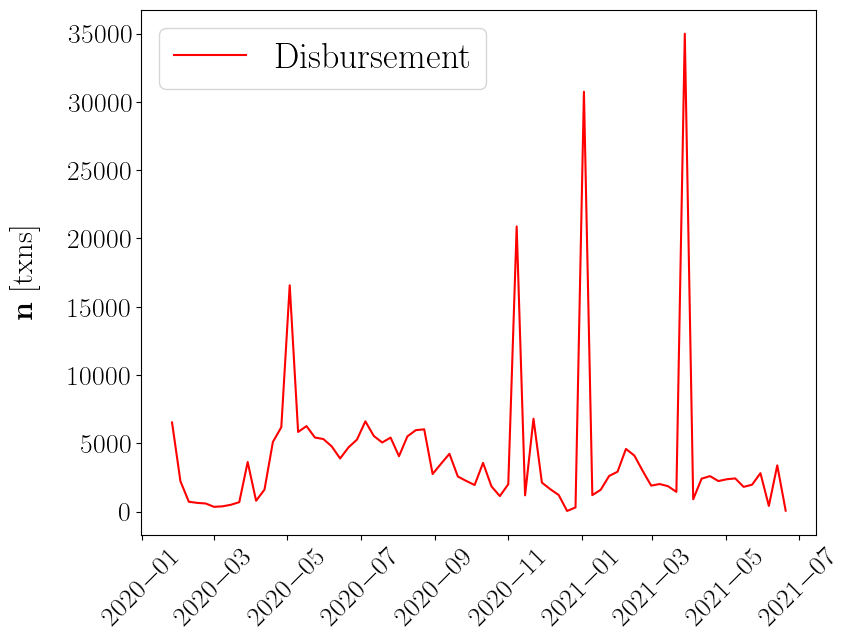

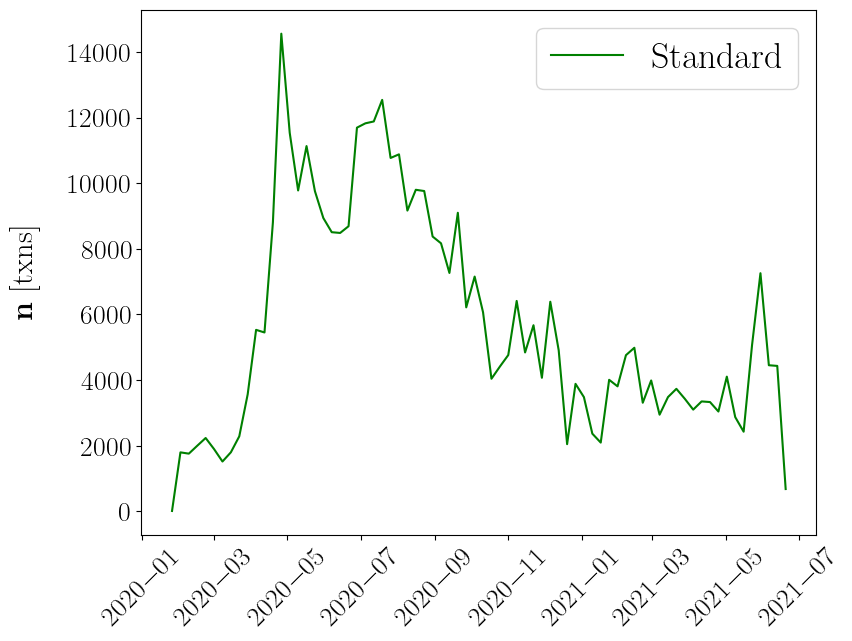

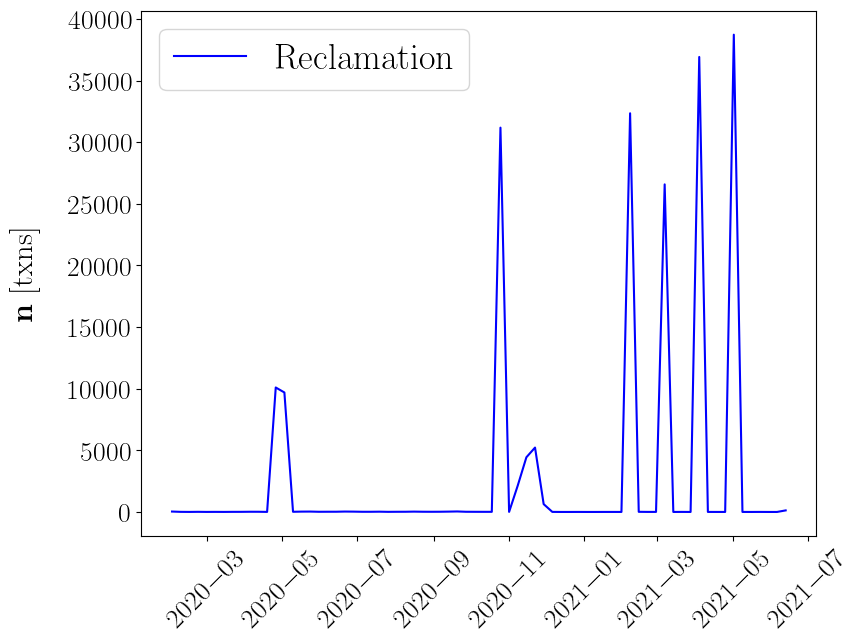

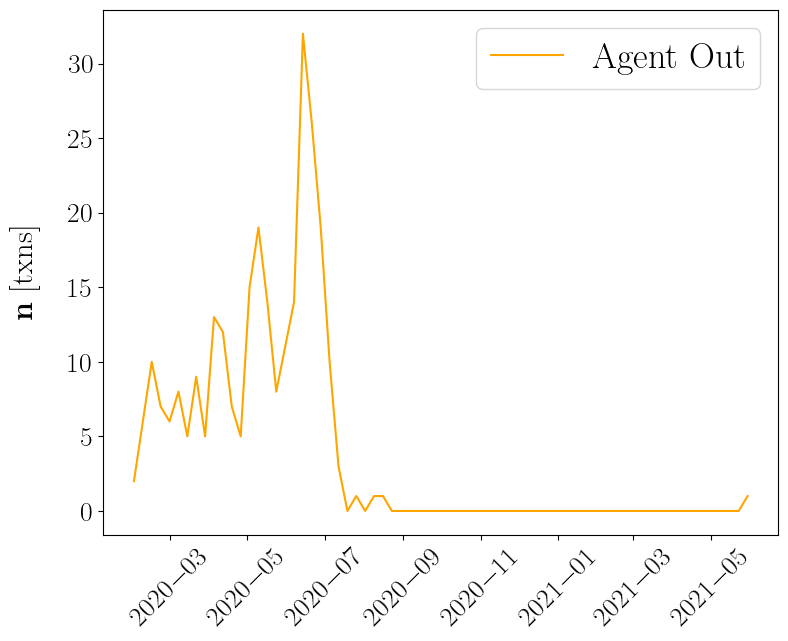

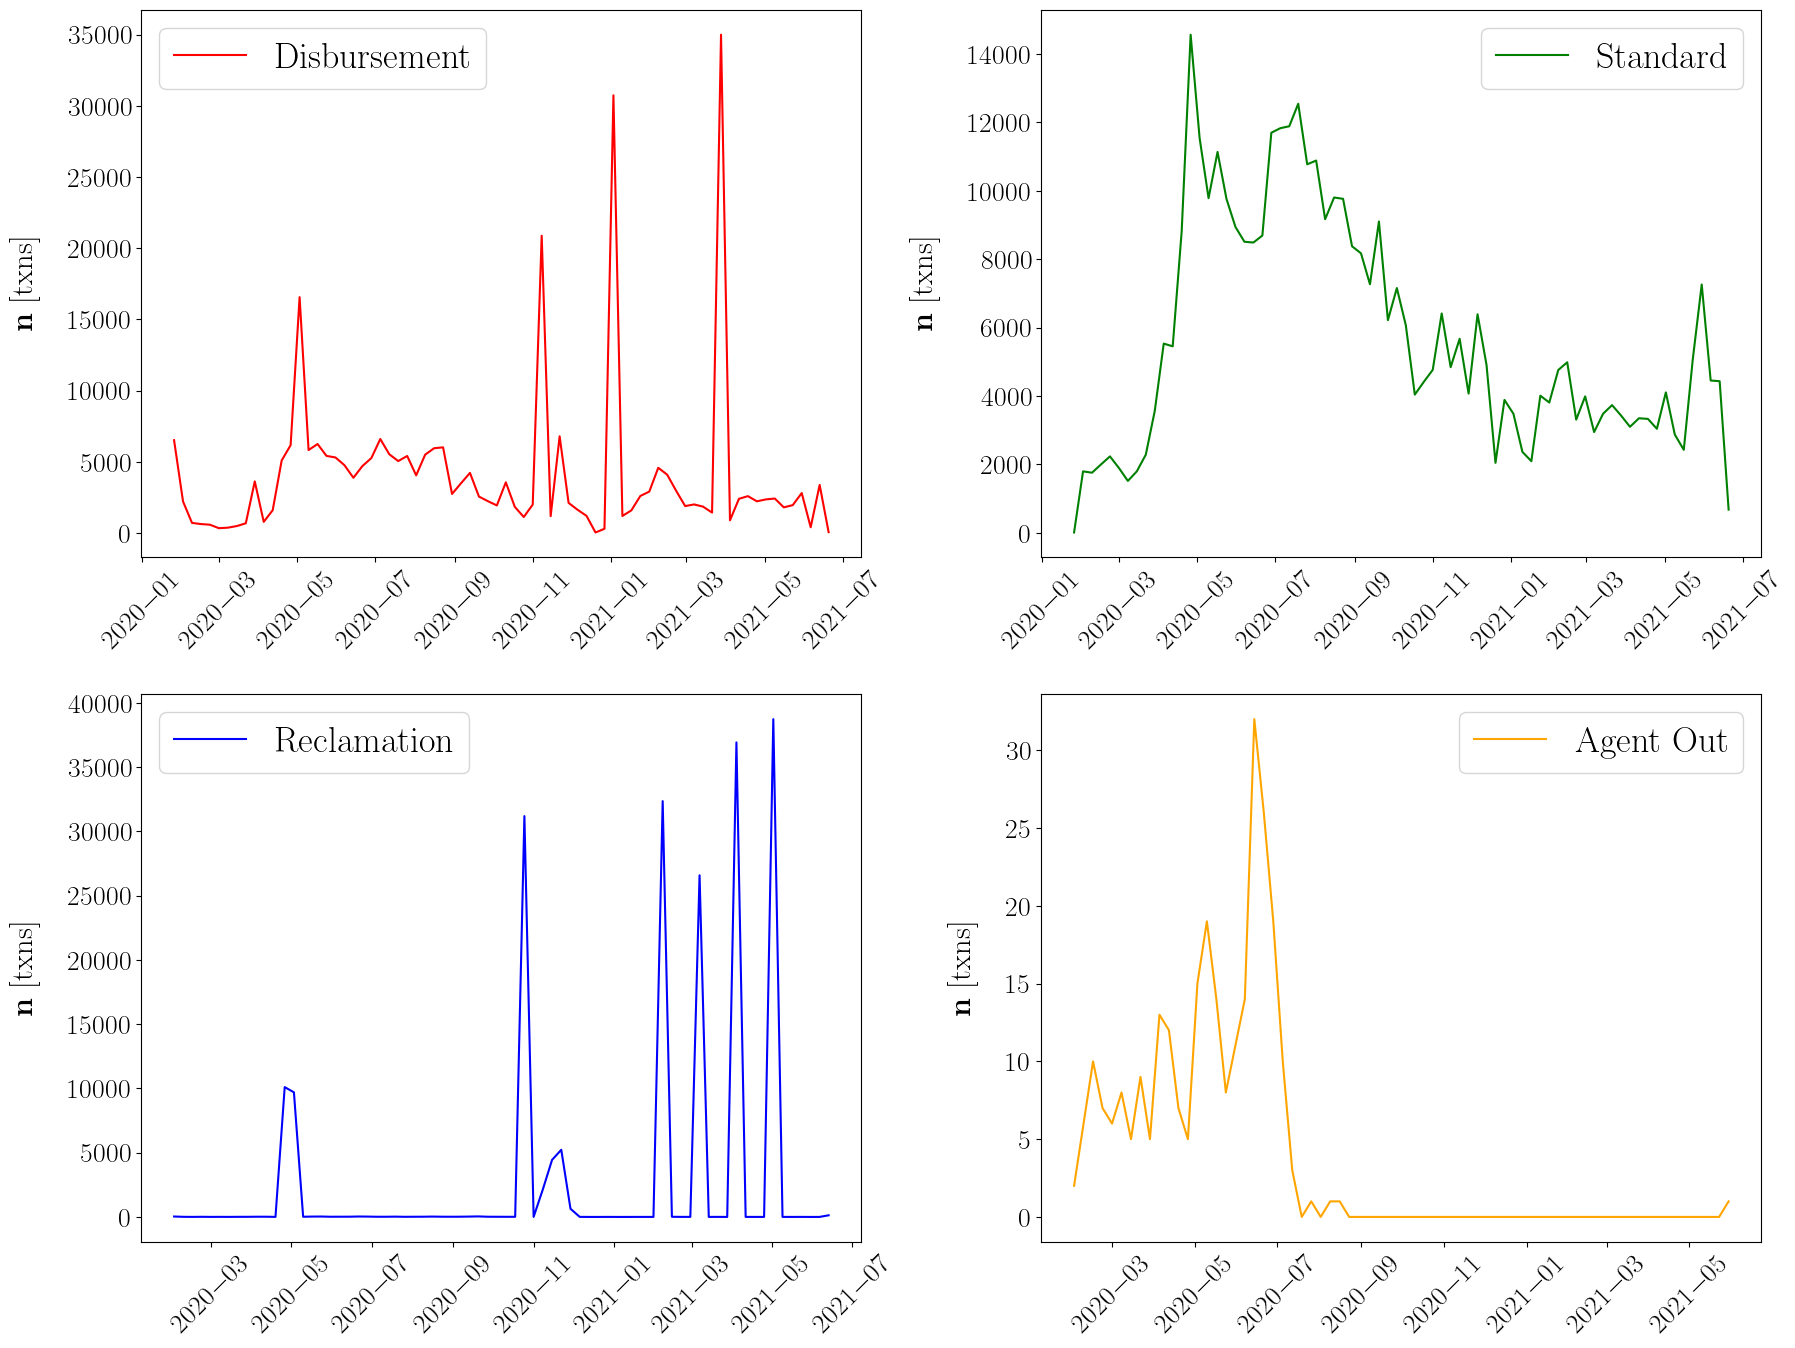

In [ ]:

colors = ['r', 'g', 'b', 'orange']

def plot_one_type(ax, txdf, typo, color):
    # weekly counts
    s = txdf[txdf.type == typo].resample('W', on='date').weight.count()

    ax.plot(s, color=color, label=typo.replace('_', ' ').title())

    ax.tick_params(axis='x', rotation=45, labelsize=20)
    ax.tick_params(axis='y', labelsize=20)
    ax.set_ylabel(r'$\textbf{n}$ [txns]', labelpad=20, fontsize=22)
    ax.legend()

# ---- 1) Create 4 separate figures (each 9x7) with identical axes box ----
types = list(TXDF.type.unique())[:4]  # keep first 4 (or remove [:4] if you always have 4)

single_figs = []
single_axes = []

for i, typo in enumerate(types):
    fig, ax = plt.subplots(figsize=(W,H), constrained_layout=False)

    # fixed margins -> identical axes box across all single figs
    fig.subplots_adjust(left=0.2, bottom=0.2, right=0.95, top=0.95)

    plot_one_type(ax, TXDF, typo, colors[i])

    single_figs.append(fig)
    single_axes.append(ax)
    fig.savefig(FIGURES / f"txtype_{typo}.pdf",
                format='pdf'
                #  dpi=300,
                #    bbox_inches="tight"
                )


# optionally save singles
# for fig, typo in zip(single_figs, types):
#     fig.savefig(FIGURES / f"txtype_{typo}.pdf", dpi=200)

# ---- 2) Combined 2x2 figure (re-draw the same plots) ----
R,C = 2,2

fig2, axs = plt.subplots(R, C, figsize=(W*C, H*R), constrained_layout=False)

# fixed margins + fixed inter-panel spacing -> identical axes boxes inside the grid
fig2.subplots_adjust(left=0.08, bottom=0.10, right=0.98, top=0.98, wspace=0.25, hspace=0.25)

for ax, (i, typo) in zip(axs.ravel(), enumerate(types)):
    plot_one_type(ax, TXDF, typo, colors[i])

# optional: add a global title
# fig2.suptitle("Weekly transaction counts by type", fontsize=24)
fig2.savefig(FIGURES / "txtype_2x2.pdf",
             format="pdf",
            #   dpi=300,
            #  bbox_inches="tight"
            )

plt.show()


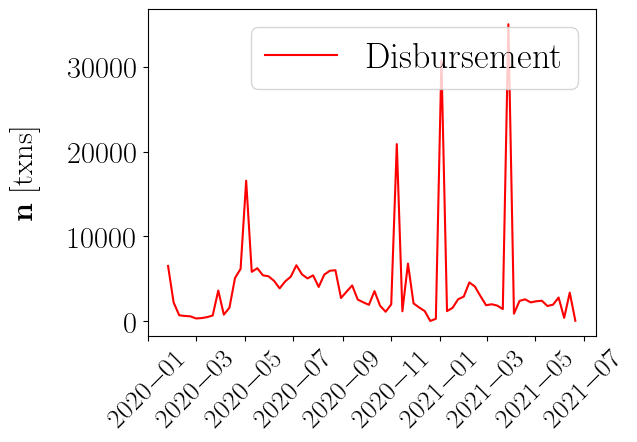

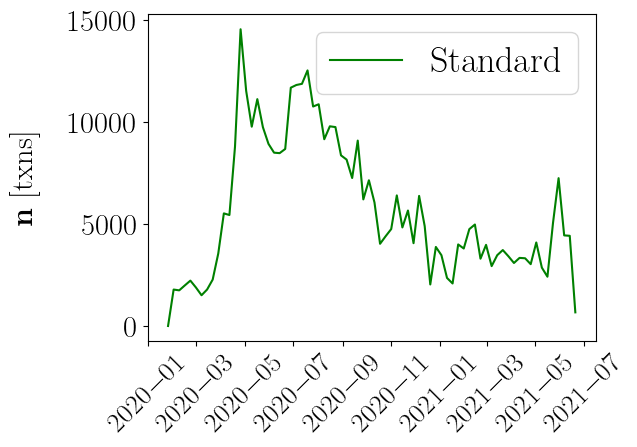

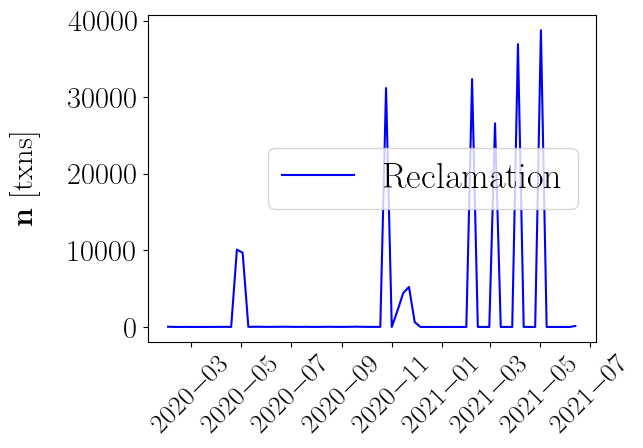

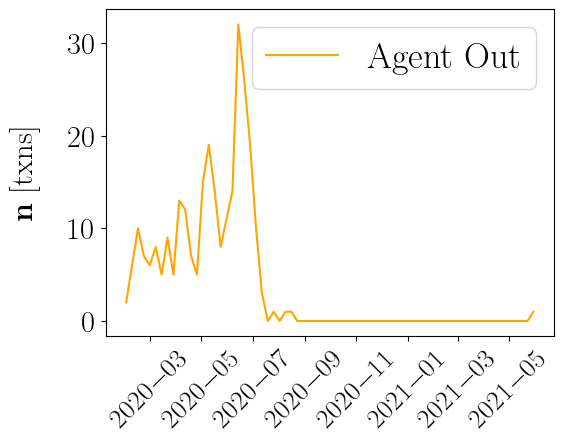

In [ ]:
# colors = ['r', 'g', 'b', 'orange']

# fig, ax = plt.subplots()

# for i, typo in enumerate(TXDF.type.unique()):
#       # Usare constrained_layout migliora la gestione dello spazio
#     plt.subplots_adjust(bottom=0.2,left=0.2)  # Evita il taglio delle label in basso
    
#     ax.plot(
#         TXDF[TXDF.type == typo].resample('W', on='date').weight.count(),
#         color=colors[i],
#         label=typo.replace('_', ' ').title()
#     )

#     ax.set_xticklabels(ax.get_xticklabels(), rotation=45, fontsize=20)  # Ruota le etichette dell'asse x
#     ax.set_ylabel(r'$\textbf{n}$ [txns]', labelpad=20, fontsize=22)
#     # plt.rcParams.update({'legend.fontsize': 26})
#     ax.legend()
#     # ax.set_le


#     # fig.savefig(FIGURES/f'/txtype_{typo}.pdf', pad_inches=2)


In [18]:
sarafu = pickle.load(open(SARAFU_PICKLED/"sarafu.pkl", "rb"))

In [22]:


def histogram(data, num_bins=31, log_bin=True, density=True):
     
    """
    Compute a histogram with configurable binning.

    Parameters:
    - data: array-like, input data
    - num_bins: int, number of bins (default: 31)
    - log_bin: bool, use logarithmic binning (default: True)
    - density: bool, normalize histogram to density (default: True)

    Returns:
    - centers: array, bin centers
    - hist: array, histogram counts
    - widths: array, bin widths
    - edges: array, bin edges
    """
    
    if len(data) == 0:
        raise ValueError("Input data must not be empty.")

    min_val, max_val = min(data), max(data)
    
    if log_bin:
        if min_val <= 0:
            # raise ValueError("Logarithmic binning requires strictly positive data.")
            data = data[data>0]
            print('Removed negative and zero values from data.')
        bins = np.logspace(np.log10(min_val), np.log10(max_val), num_bins)
    else:
        bins = np.linspace(min_val, max_val, num_bins)

    # Compute histogram
    hist, edges = np.histogram(data, bins=bins, density=density,)

    # Compute bin centers and widths
    centers = (edges[:-1] + edges[1:]) / 2
    widths = edges[1:] - edges[:-1]

    # Ensure consistent filtering
    non_zero = hist > 0
    centers, hist, widths = centers[non_zero], hist[non_zero], widths[non_zero]


    return centers, hist, widths, edges

# Preliminary analysis 

In [30]:
save=1

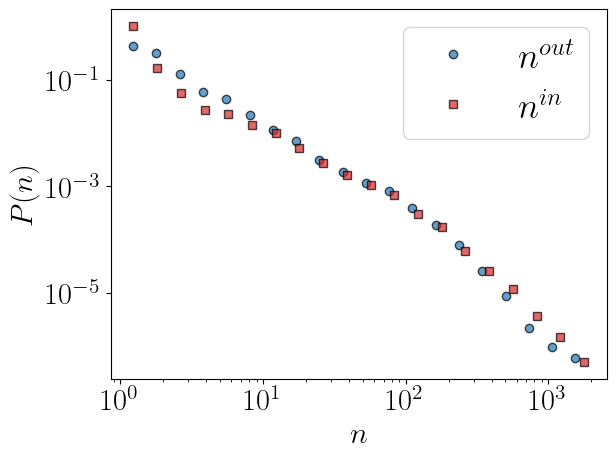

In [34]:
agents = sarafu['agents'].copy(deep=True)
colors = ['tab:blue', 'tab:red']
markers = ['o', 's']
disc = False

columns = ['tx_out', 'tx_in']
labels = [r'$n^{out}$', r'$n^{in}$']

fig, ax = plt.subplots()

for idx, col in enumerate(columns):
    data = agents[col]
    # data = agents[col]/agents[col].sum()
    xmin_plot = data[data != 0].min()  # Start plot from same min
    xmax = data.max()

    h = histogram(data,num_bins=21)
    ax.plot(h[0],h[1],
            marker=markers[idx], 
            linestyle='', 
            markeredgecolor='k',
            alpha = 0.7, 
            label=labels[idx], 
            color=colors[idx],)

# Legend and labels
ax.set_ylabel(r"$P(n)$")
ax.set_xlabel(r"$n$")

ax.set_xscale('log')
ax.set_yscale('log')
ax.legend()
# ax.grid(True)

# plt.tight_layout()
plt.show()

if save:
    fig.savefig(FIGURES/f'txintxout.pdf',
                format='pdf')


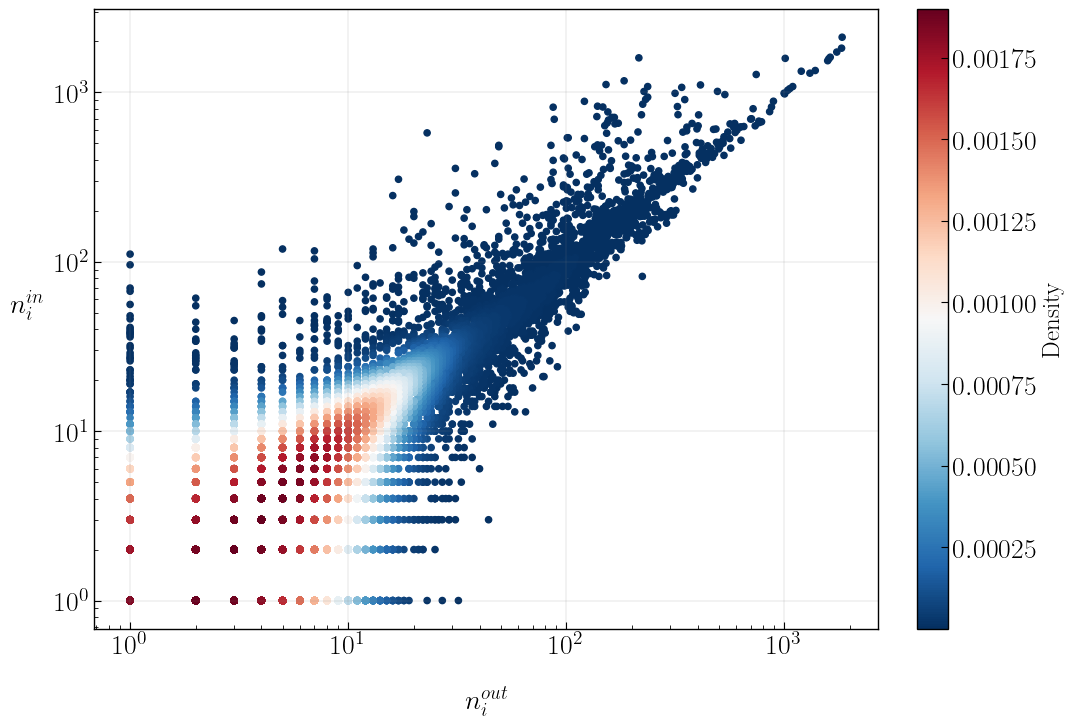

In [ ]:
data = agents[['tx_out','tx_in']].values
# agents['norm_tx_out'] = agents.tx_out/agents.tx_out.sum()
# agents['norm_tx_in'] = agents.tx_in/agents.tx_in.sum()
# data = agents[['norm_tx_out','norm_tx_in']].values

fig, ax = plt.subplots(constrained_layout=True)  # Usare constrained_layout migliora la gestione dello spazio
plt.subplots_adjust(bottom=0.2,left=0.2)  # Evita il taglio delle label in basso
xlabel = r'$n_i^{out}$'
ylabel = r'$n_i^{in}$'

plot_scatter_kde(data,ax,cmap='RdBu_r',s=20)
plt.loglog()
plt.xlabel(xlabel,rotation = 0,labelpad=20,fontsize=20)
plt.ylabel(ylabel,rotation = 0,labelpad=20,fontsize=20)
set_size(1.5*B,B,ax)
if save:
    fig.savefig(f'txintxout_corr.pdf',bbox_inches='tight', pad_inches=0.1)


pearson 0.983
kendall 0.611
spearman 0.748


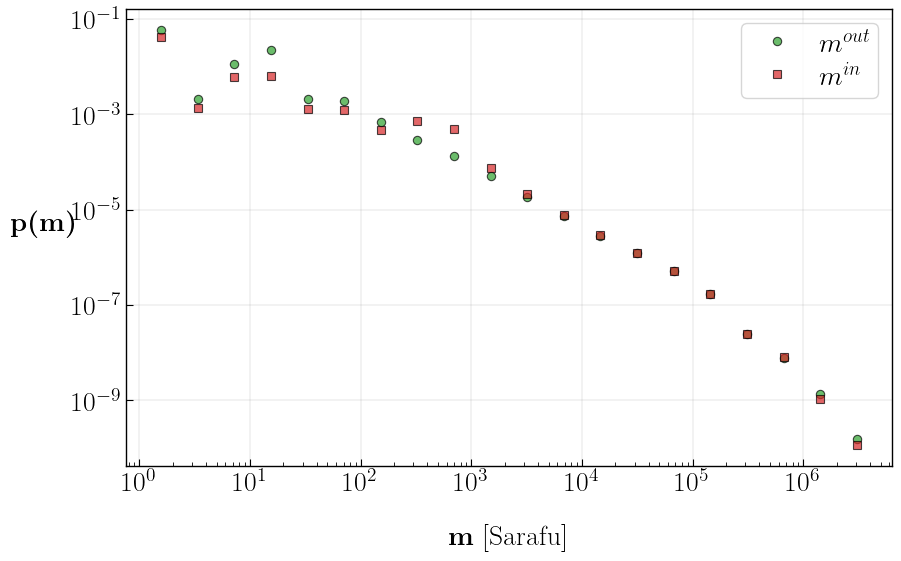

In [ ]:
data = agents[['vol_out','vol_in']]
for method in ['pearson','kendall', 'spearman']:
    print(method,data.corr(method=method).values[0,1].round(3))

fig, ax = plt.subplots(constrained_layout=True)  # Usare constrained_layout migliora la gestione dello spazio
plt.subplots_adjust(bottom=0.2,left=0.2)  # Evita il taglio delle label in basso
# ax=plt.gca()
xlabel = r'$m^{out}$'
ylabel = r'$m^{in}$'



plot_distribution(data.vol_in,ax=ax,color='tab:green',markeredgecolor='k',alpha = 0.7, linestyle='', marker='o',label = xlabel)
plot_distribution(data.vol_out,ax=ax,color='tab:red',markeredgecolor='k',alpha = 0.7, linestyle='', marker='s',label= ylabel)
plt.xlabel(r'$\textbf{m}$ [Sarafu]',rotation = 0,labelpad=20,fontsize=20)
plt.ylabel(r'$\textbf{p(m)}$',rotation = 0,labelpad=20,fontsize=20)
plt.legend(fontsize=20)


# save=0
if save:
    fig.savefig(FIGURES / f'volinvolout.pdf',bbox_inches='tight', pad_inches=0.1)

In [ ]:
# with open(FIGURES / f'sarafu_info.txt', 'a') as f:
#     print(f'Volumes correlation {data.corr().values[0,1].round(3)}',file=f)

In [29]:
B = 5.5

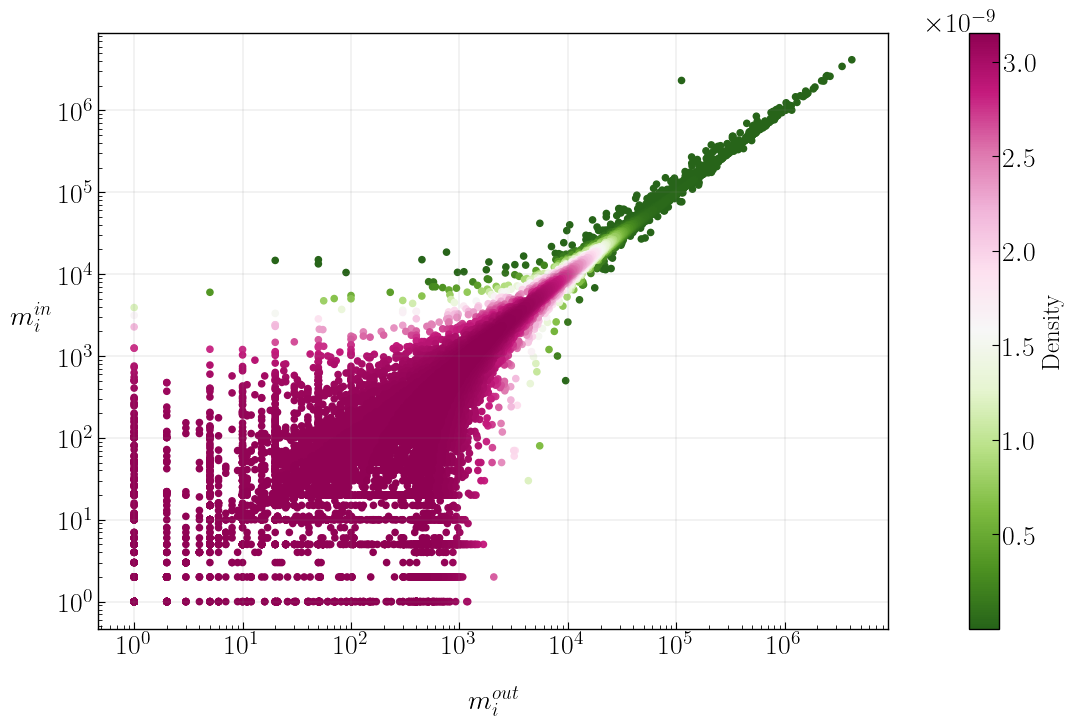

In [30]:
fig, ax = plt.subplots(constrained_layout=True)  # Usare constrained_layout migliora la gestione dello spazio
plt.subplots_adjust(bottom=0.2,left=0.2)  # Evita il taglio delle label in basso
    

xlabel = r'$m_i^{out}$'
ylabel = r'$m_i^{in}$'


plot_scatter_kde(data.values,ax,cmap='PiYG_r',s=20)
plt.loglog()
plt.xlabel(xlabel,rotation = 0,labelpad=20,fontsize=20)
plt.ylabel(ylabel,rotation = 0,labelpad=20,fontsize=20)
set_size(1.5*B,B,ax)


In [ ]:
if save:
    fig.savefig(FIGURES / f'volinvoloutcorr.pdf',bbox_inches='tight', pad_inches=0.1)

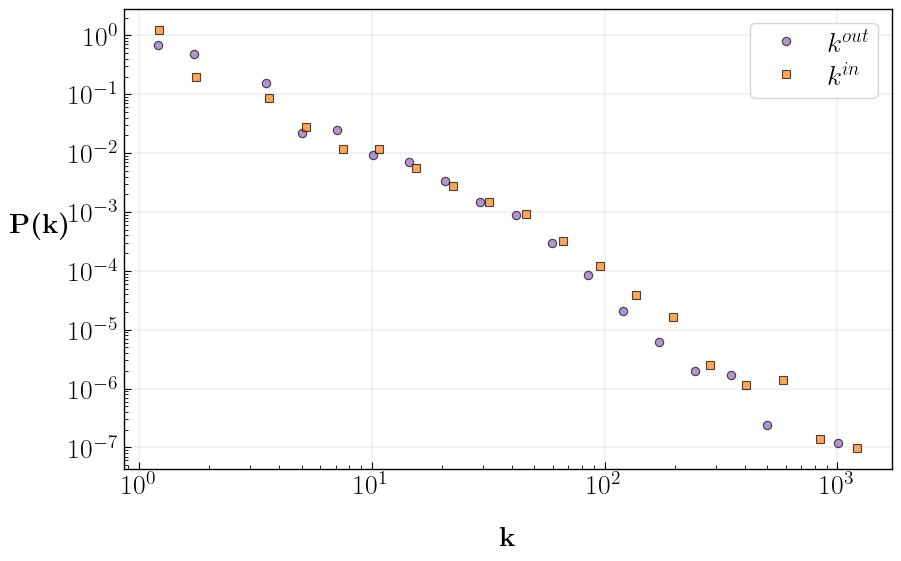

In [32]:
data = agents[['out_deg','in_deg']]

fig, ax = plt.subplots(constrained_layout=True)  # Usare constrained_layout migliora la gestione dello spazio
plt.subplots_adjust(bottom=0.2,left=0.2)  # Evita il taglio delle label in basso
    
# ax=ax
xlabel = r'$k^{out}$'
ylabel = r'$k^{in}$'
colors = ['tab:purple', 'tab:orange']

plot_distribution(data.out_deg,ax=ax,color=colors[0],markeredgecolor='k',alpha = 0.7, linestyle='', marker='o',label = xlabel)
plot_distribution(data.in_deg,ax=ax,color=colors[1],markeredgecolor='k',alpha = 0.7, linestyle='', marker='s',label= ylabel)
plt.xlabel(r'$\textbf{k}$',rotation = 0,labelpad=20,fontsize=20)
plt.ylabel(r'$\textbf{P(k)}$',rotation = 0, labelpad=20,fontsize=20)
plt.legend(fontsize=20)

In [ ]:
if save:
    fig.savefig(FIGURES / f'degindegout.pdf',bbox_inches='tight', pad_inches=0.1)

Text(0, 0.5, '$k_i^{in}$')

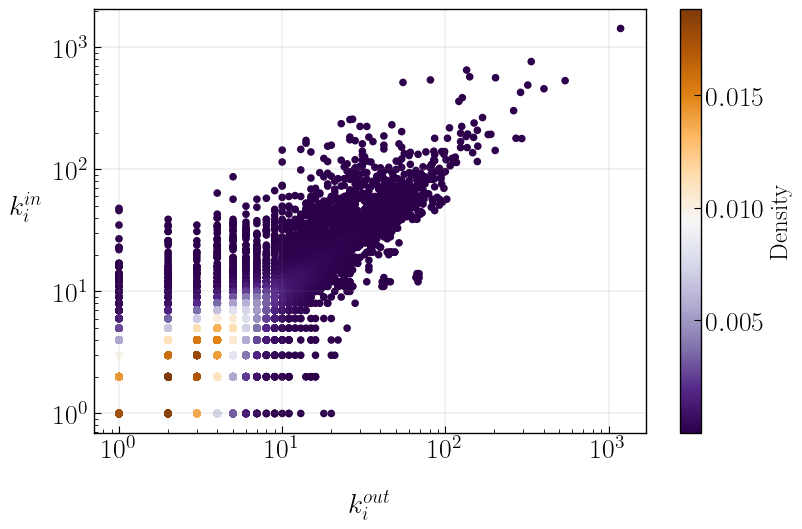

In [34]:
fig,ax=plt.subplots()
xlabel = r'$k_i^{out}$'
ylabel = r'$k_i^{in}$'
plot_scatter_kde(data.values,ax,cmap='PuOr_r',s=20)
plt.loglog()
plt.xlabel(xlabel,rotation = 0,labelpad=20,fontsize=20)
plt.ylabel(ylabel,rotation = 0,labelpad=20,fontsize=20)

In [ ]:
if save:
    fig.savefig(FIGURES / f'degindegoutcorr.pdf',bbox_inches='tight', pad_inches=0.1)

Text(0, 0.5, '$\\textbf{p}(\\langle q_i \\rangle)$')

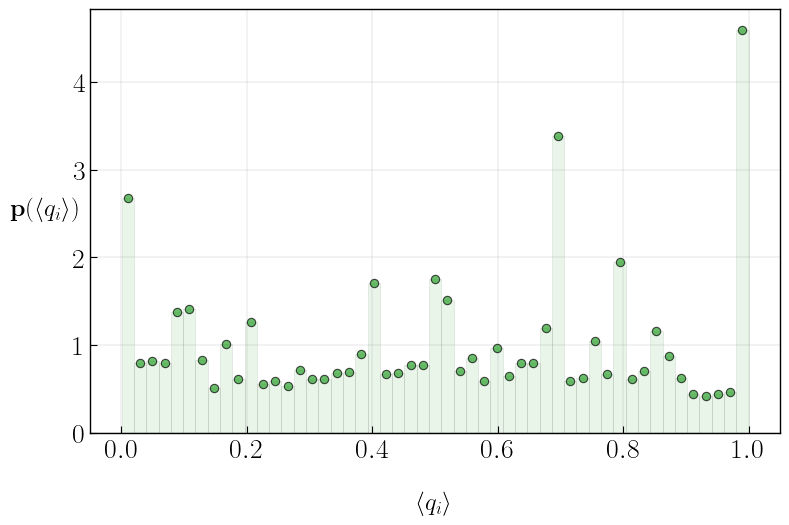

In [36]:
# plot_distribution(tx.groupby('source').frac_out.mean())
# data = tx.groupby('source').frac_out.mean()
data = agents.mean_frac_out

xlabel = r'$\langle q_i \rangle$'
ylabel = r"$\textbf{p}(\langle q_i \rangle)$"

fig,ax=plt.subplots()
plt.hist(data,edgecolor='k',alpha = 0.1,color='tab:green', bins=51,density = True, linewidth=0.5,align='mid')
# plt.hist(data2,edgecolor='k',alpha = 0.7,color='tab:red', bins=51,density = True, linewidth=0.5)

plot_distribution(data,ax=ax,color='tab:green',markeredgecolor='k',alpha = 0.7, linestyle='', marker='o',log_bin=False,log_scale=False,n_bins=51)
plt.xlabel(xlabel,rotation=0,labelpad=20)
plt.ylabel(ylabel,rotation=0,labelpad=20)

In [ ]:
if save:
    fig.savefig(FIGURES / f'spending_shares.pdf',bbox_inches='tight', pad_inches=0.1)

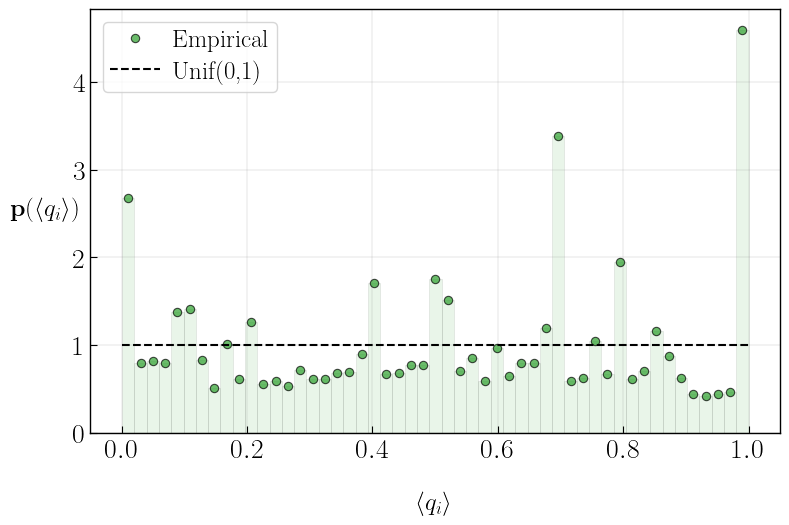

In [ ]:
# plot_distribution(tx.groupby('source').frac_out.mean())
# data = tx.groupby('source').frac_out.mean()
data = agents.mean_frac_out

xlabel = r'$\langle q_i \rangle$'
ylabel = r"$\textbf{p}(\langle q_i \rangle)$"

fig,ax=plt.subplots()
plt.hist(data,edgecolor='k',alpha = 0.1,color='tab:green', bins=51,density = True, linewidth=0.5,align='mid')
# plt.hist(data2,edgecolor='k',alpha = 0.7,color='tab:red', bins=51,density = True, linewidth=0.5)

plot_distribution(data,ax=ax,color='tab:green',markeredgecolor='k',alpha = 0.7, linestyle='', marker='o',log_bin=False,log_scale=False,n_bins=51,label="Empirical")
plt.xlabel(xlabel,rotation=0,labelpad=20)
plt.ylabel(ylabel,rotation=0,labelpad=20)
plt.plot([0,1],[1,1],'k--',label="Unif(0,1)")
plt.legend()

if save:
    fig.savefig(FIGURES / f'spending_shares_presentation.pdf',bbox_inches='tight', pad_inches=0.1)

Text(0, 0.5, '$\\textbf{p}(q)$')

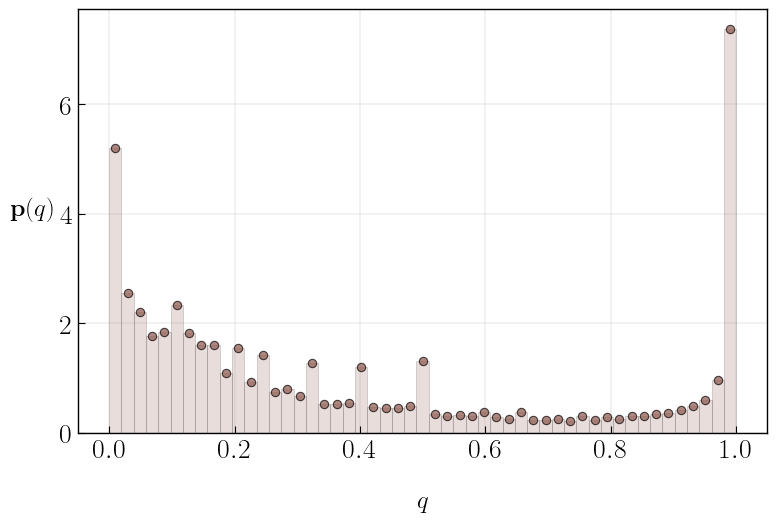

In [39]:
# plot_distribution(tx.frac_out)
bins = 51
data = tx.frac_out

fig = plt.figure()
plt.hist(data, bins=bins,edgecolor='k',color='tab:brown',density=True,alpha=0.2,linewidth=0.5,align='mid')
plot_distribution(data,ax=plt.gca(),color='tab:brown',markeredgecolor='k',alpha = 0.7, linestyle='', marker='o',log_bin=False,log_scale=False,n_bins=51)

xlabel = r'$q$'
ylabel = r'$\textbf{p}(q)$' 

plt.xlabel(xlabel,rotation=0,labelpad=20)
plt.ylabel(ylabel,rotation=0,labelpad=20)





In [ ]:
if save:
    fig.savefig(FIGURES / f'spending_spectrum.pdf',bbox_inches='tight', pad_inches=0.1)

Text(0, 0.5, '$\\mathbf{p(w)}$')

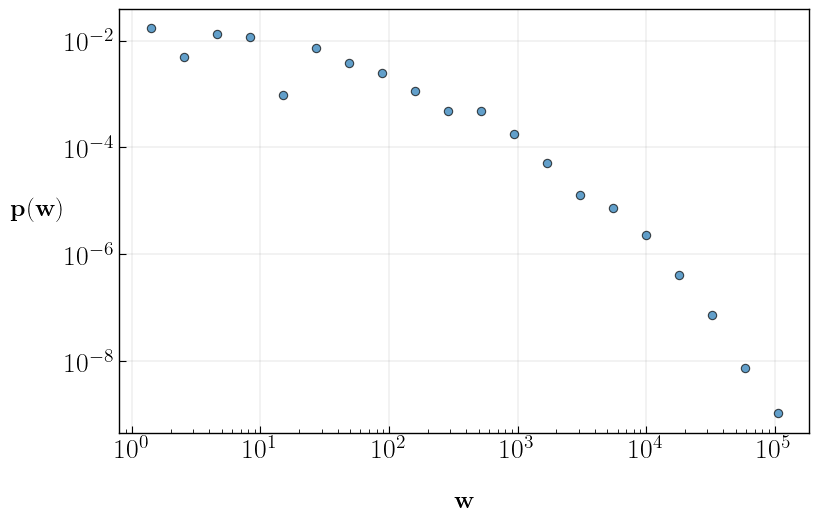

In [41]:
fig = plt.figure()
plot_distribution(tx.weight,marker = 'o',linestyle='',markeredgecolor='k',alpha = 0.7,ax=plt.gca())
plt.xlabel(r'$\mathbf{w}$',rotation=0,labelpad=20)
plt.ylabel(r'$\mathbf{p(w)}$',rotation=0,labelpad=20)


In [ ]:
if save:
    fig.savefig(FIGURES / f'weight.pdf',bbox_inches='tight', pad_inches=0.1)

In [43]:
def balance_constructor(txdf):
    """
    Constructs a balance record DataFrame from transaction data.

    Parameters:
    txdf (DataFrame): Input DataFrame containing at least:
                      ['date', 'source', 'target', 'source_bal_post', 'target_bal_post']

    Returns:
    DataFrame: A DataFrame with columns ['date', 'crid', 'balance'] tracking balance changes.
    """
    # Ensure input has the required columns
    required_cols = ['date', 'source', 'target', 'source_bal_post', 'target_bal_post','weight']
    if not all(col in txdf.columns for col in required_cols):
        raise ValueError(f"Missing required columns in input DataFrame: {set(required_cols) - set(txdf.columns)}")

    # Construct balance records for source and target
    balances = pd.DataFrame({
        'date': txdf['date'].repeat(2).values,  # Repeat each transaction twice for source and target
        'crid': pd.concat([txdf['source'], txdf['target']], ignore_index=True),  # User identifiers
        'balance': pd.concat([txdf['source_bal_post'], txdf['target_bal_post']], ignore_index=True),  # Balances
        'type' : txdf['type'].repeat(2).values,
        'tx_id': txdf['id'].repeat(2).values,
        'weight': txdf.weight.repeat(2).values,
        # 'period': txdf['period'].repeat(2).values
    })

    return balances


In [44]:
all_balances = balance_constructor(TXDF[['date','source','target','source_bal_post','target_bal_post','type','id','weight']])

all_balances['period'] = pd.cut(all_balances.date, bins=20,labels=False) #period by date

# all_balances['period'] = pd.cut(all_balances.index, bins=20,labels=False) #period by nr of txns


filtered_balances = all_balances.loc[(all_balances.crid.isin(filtered_crid)) & (all_balances.type == 'STANDARD') & (all_balances.weight >= 1)]

bal_pivot = pd.pivot_table(filtered_balances, index='crid',columns='period', values='balance', aggfunc='last')
bal_pivot = bal_pivot.ffill(axis=1)

js_test_balances = compute_sequential_js(bal_pivot)
# plt.plot()

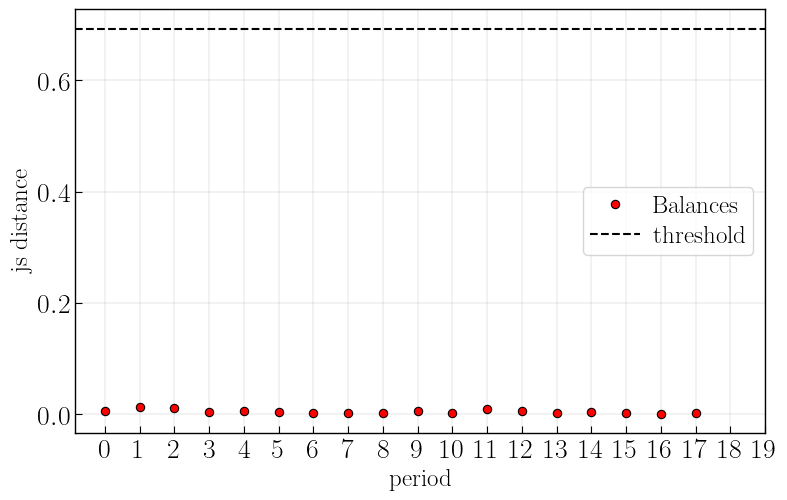

In [45]:
fig = plt.figure()
plt.plot(js_test_balances.values(),'ro',label = 'Balances')
plt.axhline(y=np.log(2), label='threshold', color='k', linestyle='--')
plt.xlabel('period')
plt.ylabel('js distance')
plt.xticks(np.arange(0, 20, 1))
plt.legend()


In [ ]:
if save:
    fig.savefig(FIGURES / f'bal_stationary.pdf',bbox_inches='tight', pad_inches=0.1)

In [47]:
data = bal_pivot.iloc[:,-1]
data = data[data>=1]

Text(0, 0.5, '$\\mathbf{p(b)}$')

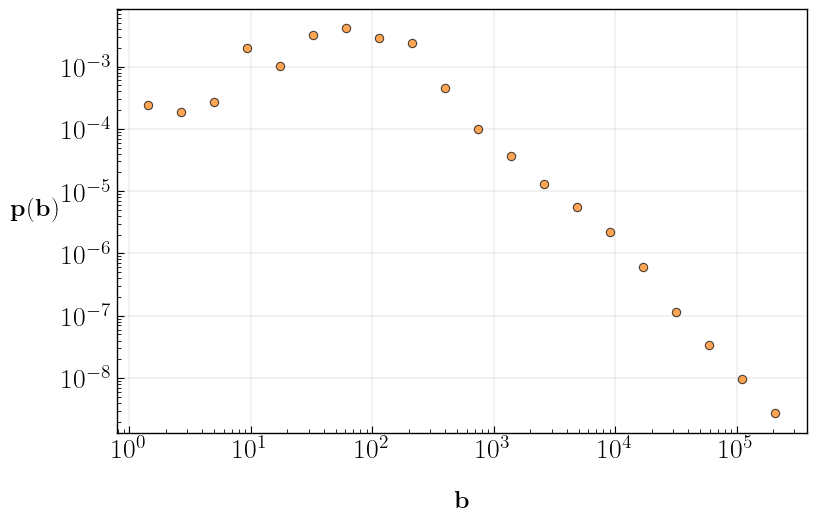

In [48]:
fig = plt.figure()

line1 = plot_distribution(data,ax=plt.gca(),marker='o',markeredgecolor='k',linestyle='',alpha = 0.7,color='tab:orange')
plt.xlabel(r'$\mathbf{b}$',rotation=0,labelpad=20)
plt.ylabel(r'$\mathbf{p(b)}$',rotation=0,labelpad=20)


Text(0, 0.5, '$\\mathbf{p(b)}$')

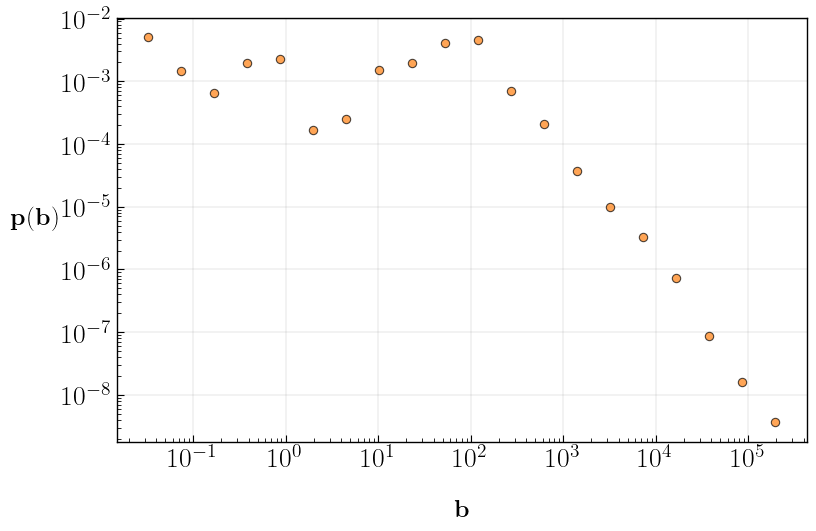

In [49]:
fig = plt.figure()
line1 = plot_distribution(bal_pivot.iloc[:,-1],ax=plt.gca(),marker='o',markeredgecolor='k',linestyle='',alpha = 0.7,color='tab:orange')
plt.xlabel(r'$\mathbf{b}$',rotation=0,labelpad=20)
plt.ylabel(r'$\mathbf{p(b)}$',rotation=0,labelpad=20)


In [ ]:

if save:
    fig.savefig(FIGURES / f'final_bal.pdf',bbox_inches='tight', pad_inches=0.1)


Text(0, 0.5, '$\\mathbf{p(x)}$')

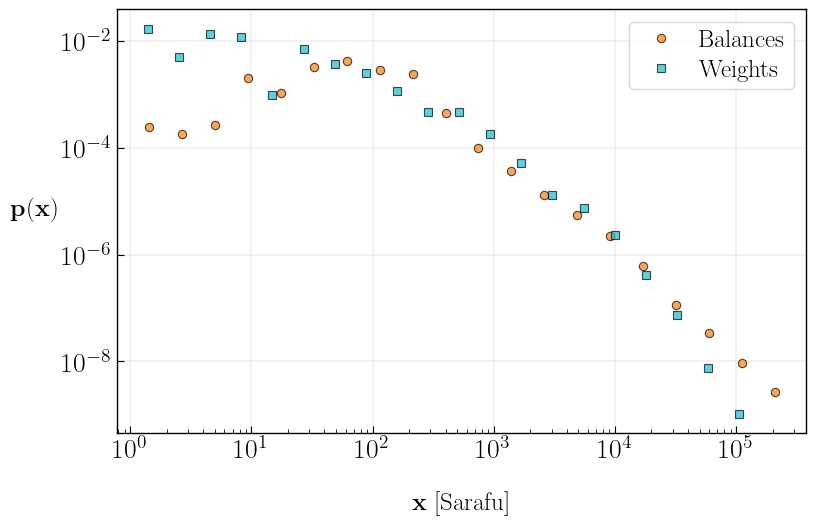

In [51]:
fig = plt.figure()
# plot_distribution(bal_pivot.iloc[:,-1],ax=plt.gca(),marker='o',markeredgecolor='k',linestyle='',alpha = 0.7,color='tab:orange',label='b')
plot_distribution(data,ax=plt.gca(),marker='o',markeredgecolor='k',linestyle='',alpha = 0.7,color='tab:orange',label='Balances')

plot_distribution(tx.weight,marker = 's',linestyle='',markeredgecolor='k',alpha = 0.7,ax=plt.gca(),label='Weights', color = 'tab:cyan')
plt.xlabel(r'$\mathbf{x}$ [Sarafu]',rotation=0,labelpad=20)
plt.ylabel(r'$\mathbf{p(x)}$',rotation=0,labelpad=20)


In [ ]:

if save:
    fig.savefig(FIGURES / f'weightandbalance.pdf',bbox_inches='tight', pad_inches=0.1)

In [53]:
agents.loc[:,['tx_in', 'tx_out']].min()

tx_in     1.0
tx_out    1.0
dtype: float64

# Fits

In [40]:
from local_utils import recalculate_constant, powerlaw_function
from myutils import plot_distribution

Chosen xmin for tx_out: 2.0
KS Statistic: 0.04353955946263399
Quantile of data used for the fit: 0.8061 (80.61%)
Chosen xmin for tx_in: 1.0
KS Statistic: 0.0811173462219753
Quantile of data used for the fit: 1.0000 (100.00%)


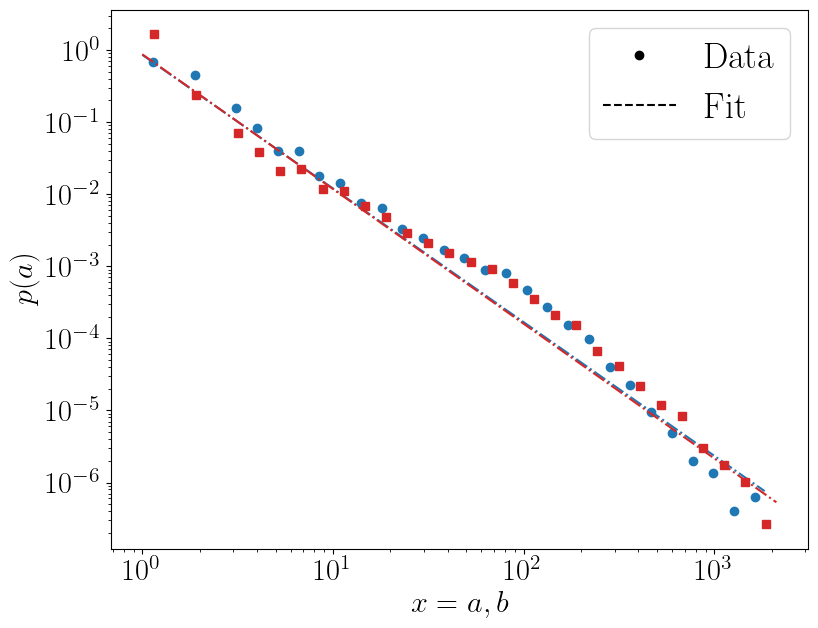

In [51]:

# Boolean flag to control fitting
perform_fit = 1

alpha = {}
c = {}
colors = ['tab:blue', 'tab:red']
markers = ['o', 's']
disc = False

if perform_fit:
    columns = ['tx_out', 'tx_in']
    labels = [r'$n^{out}(T)$', r'$n^{in}(T)$']
#     if disc:
#         columns = ['tx_out', 'tx_in']
#         labels = [r'$n^{out}$', r'$n^{in}$']
#     else:
#         # columns = ['activity', 'attractiveness']
        
# else:
#     labels = [r'$n^{out}$', r'$n^{in}$']
#     columns = ['tx_out', 'tx_in']


r,c = 1,1
fig, ax = plt.subplots(r,c,figsize=(W,H))
fits = {}

for idx, col in enumerate(columns):
    data = agents[col]
    # data = agents[col]/agents[col].sum()
    xmin_plot = data[data != 0].min()  # Start plot from same min
    xmax = data.max()

    # Automatically determine xmin for 20% quantile
    # xmin_fit = find_xmin_by_quantile(data, quantile=0.30)
    xmin_fit = data.quantile(0.30)

    if perform_fit:
        # Fit power-law model
        fit = pwl.Fit(data, xmin=xmin_fit, xmax=xmax, discrete=disc, estimator='Hill', estimate_discrete=disc)
        alpha[col] = fit.power_law.alpha
        xmin_fit = fit.xmin
        xmax = data.max()
        
        print(f"Chosen xmin for {col}: {xmin_fit}")
        print(f"KS Statistic: {fit.D}")
        q = np.sum(data >= xmin_fit) / len(data)
        print(f"Quantile of data used for the fit: {q:.4f} ({q * 100:.2f}%)")

        # Recalculate C for full range
        C_adjusted = recalculate_constant(alpha[col], xmin_plot, xmax)
        
        if disc:
            CC = fit.power_law._pdf_discrete_normalizer
        else:
            CC = fit.power_law._pdf_continuous_normalizer

        # Generate x-values for fitted curve starting from xmin_plot
        x = np.logspace(np.log10(xmin_plot), np.log10(xmax), 1000)
        y = powerlaw_function(x, alpha=alpha[col], xmin=xmin_plot, C=C_adjusted)

        # Plot adjusted power-law fit
        ax.plot(x, y, 
                # label=r'PL Fit, $\alpha$ = %.2f' % alpha[col], 
                color=colors[idx], linestyle='-.')

        fits[col] = {'alpha':fit.power_law.alpha, 'xmin':fit.xmin, 'xmax':fit.xmax}
        with open('sarafu_info.txt','a') as f:
            print(f'Power-law fit for {col}: alpha = {fit.power_law.alpha}, xmin = {fit.xmin}, xmax = {fit.xmax}',file=f)
    # Plot empirical distribution
    h = histogram(data)
    ax.plot(h[0], h[1], color=colors[idx], marker=markers[idx], linestyle='', 
            # label=labels[idx]
            )
    # plot_distribution(
    #     # agents[col],
    #     data,
    #     marker=markers[idx], 
    #     linestyle='', 
    #     markeredgecolor='k',
    #     alpha = 0.7, 
    #     label=labels[idx], 
    #     color=colors[idx],
    #     ax=ax
    # )



# Legend and labels
if perform_fit:
    ax.set_ylabel(r"$p(a)$")
    ax.set_xlabel(r"$x = a,b$")
else:
    ax.set_ylabel(r"$P(x)$")
    ax.set_xlabel(r"$x = a,b$")

ax.set_xscale('log')
ax.set_yscale('log')
legend_elements = [
    Line2D([0], [0], linestyle="",marker='o', color="black", label="Data"),
    Line2D([0], [0], linestyle="--", marker=None, color="black",
           label="Fit"),
    # Line2D([0], [0], linestyle="-", color="C0", label="Final Balances"),
    # Line2D([0], [0], linestyle="-", color="C1", label="Transaction Sizes"),
]
ax.legend(handles=legend_elements)
# ax.grid(True)

# plt.tight_layout()
plt.show()


save = 1
if save:
    fig.savefig(FIGURES/f'actattr_fit.pdf',
                format='pdf'
    # bbox_inches='tight', pad_inches=0.1
    )

In [54]:
#TRANSACTIONS DF FILTERS
standard_tx = lambda tx: tx.type == 'STANDARD'
good_users = lambda tx: ~tx.source.isin(BAD_USERS) | ~tx.target.isin(BAD_USERS)
std_roles = lambda tx: tx.source_role.isin(['BENEFICIARY','GROUP_ACCOUNT','VENDOR']) | tx.target_role.isin(['BENEFICIARY','GROUP_ACCOUNT','VENDOR'])   
standard = lambda tx: standard_tx(tx) & good_users(tx) & std_roles(tx)

disbursement = lambda tx: tx.type == 'DISBURSEMENT'
withdrawal = lambda tx: tx.type.isin(['RECLAMATION','AGENT_OUT'])

from_kinango = lambda tx: tx.source_area == 'Kinango Kwale'
to_kinango = lambda tx: tx.target_area == 'Kinango Kwale'
just_kinango = lambda tx: from_kinango(tx) & to_kinango(tx) 

from_mukuru = lambda tx: tx.source_area == 'Mukuru Nairobi'
to_mukuru = lambda tx: tx.target_area == 'Mukuru Nairobi'
just_mukuru = lambda tx: from_mukuru(tx) & to_mukuru(tx) 


#BalanceS DFS FILTERS
balxmin = lambda bal,feat,tau: bal[feat]>=tau
balxinf = lambda bal,feat,tau: bal[feat]>tau
balxmax = lambda bal,feat,tau: bal[feat]<=tau
balxsup = lambda bal,feat,tau: bal[feat]<tau

#AGENTS DFS FILTERS
agxmin = lambda ag,feat,tau: ag[feat]>=tau
agxinf = lambda ag,feat,tau: ag[feat]>tau
agxmax = lambda ag,feat,tau: ag[feat]<=tau
agxsup = lambda ag,feat,tau: ag[feat]<tau


In [61]:
def balance_constructor(tx_with_bal, users, bins = 20, index = None):

    if 'period' not in tx_with_bal.columns:
        print('Adding period column to txns dataframe...')
        if index is None:
            tx_with_bal['period'] = pd.cut(tx_with_bal.index, bins=bins,labels=False)
        if index is not None:
            tx_with_bal['period'] = pd.cut(tx_with_bal[index], bins=bins,labels=False)
    else: 
        print('period already in txns dataframe')

    balances_pre = pd.DataFrame({
        'id': tx_with_bal['id'].repeat(2).values,
        'date': tx_with_bal['date'].repeat(2).values,  # Repeat each time twice
        'balance': tx_with_bal[['source_bal_pre', 'target_bal_pre']].values.flatten(),
        'xdai': tx_with_bal[['source_xdai', 'target_xdai']].values.flatten(),  # Stack feature1 and feature2 in an alternating pattern
        'type': tx_with_bal['type'].repeat(2).values,
        'period':tx_with_bal['period'].repeat(2).values,
        'weight': tx_with_bal['weight'].repeat(2) * np.tile([-1,1],len(tx_with_bal)),
        'kind': np.tile(['source','target'],len(tx_with_bal))
    })

    balances_post = pd.DataFrame({
        'id': tx_with_bal['id'].repeat(2).values,
        'date': tx_with_bal['date'].repeat(2).values,  # Repeat each time twice
        'balance': tx_with_bal[['source_bal_post', 'target_bal_post']].values.flatten(),
        'xdai': tx_with_bal[['source_xdai', 'target_xdai']].values.flatten(),  # Stack feature1 and feature2 in an alternating pattern
        'type': tx_with_bal['type'].repeat(2).values,
        'period':tx_with_bal['period'].repeat(2).values,
        'weight': tx_with_bal['weight'].repeat(2) * np.tile([-1,1],len(tx_with_bal)),
        'kind': np.tile(['source','target'],len(tx_with_bal))
    })

    balances_pre.balance = balances_pre.balance.apply(lambda x: 0 if abs(x) < 1e-3 else x)
    balances_post.balance = balances_post.balance.apply(lambda x: 0 if abs(x) < 1e-3 else x)
    
    balances_pre = balances_pre.merge(
        users[['xdai', 'role', 'area_type', 'area_name','svol_in', 'svol_out','stxns_in', 'stxns_out', 'sunique_in', 'sunique_out','initial_bal','final_bal','net','otxns_in', 'otxns_out','crid']],  # Ensure the right columns are selected
        on='xdai',  # Use 'xdai' as the merge key in users
        how='left'
    )
    balances_post = balances_post.merge(
        users[['xdai', 'role', 'area_type', 'area_name','svol_in', 'svol_out','stxns_in', 'stxns_out', 'sunique_in', 'sunique_out','initial_bal','final_bal','net','otxns_in', 'otxns_out','crid']],  # Ensure the right columns are selected
        on='xdai',  # Use 'xdai' as the merge key in users
        how='left'
    )

    return balances_pre, balances_post

def scale_vect(arr):
    return (arr-min(arr))/(max(arr)-min(arr))

period already in txns dataframe


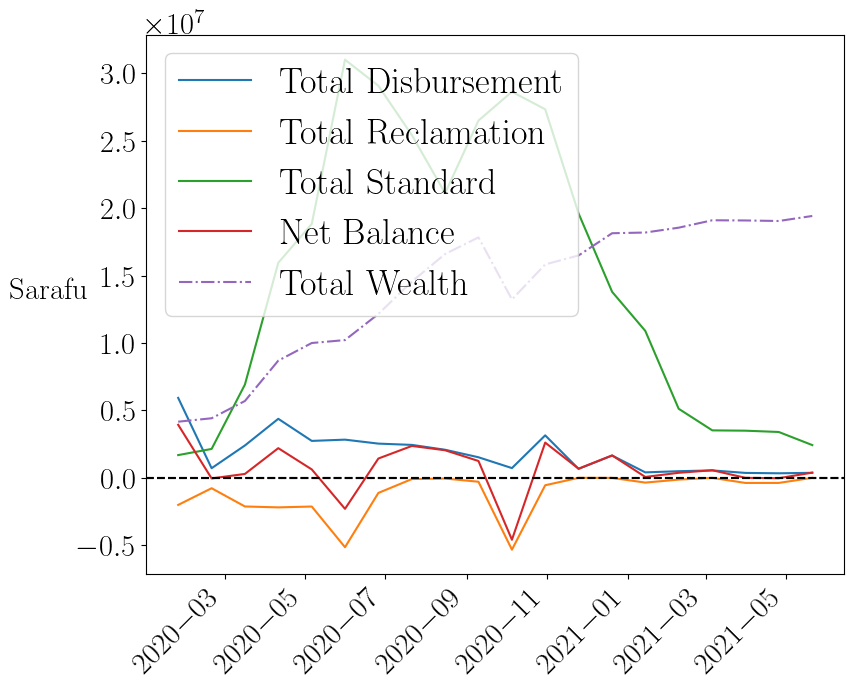

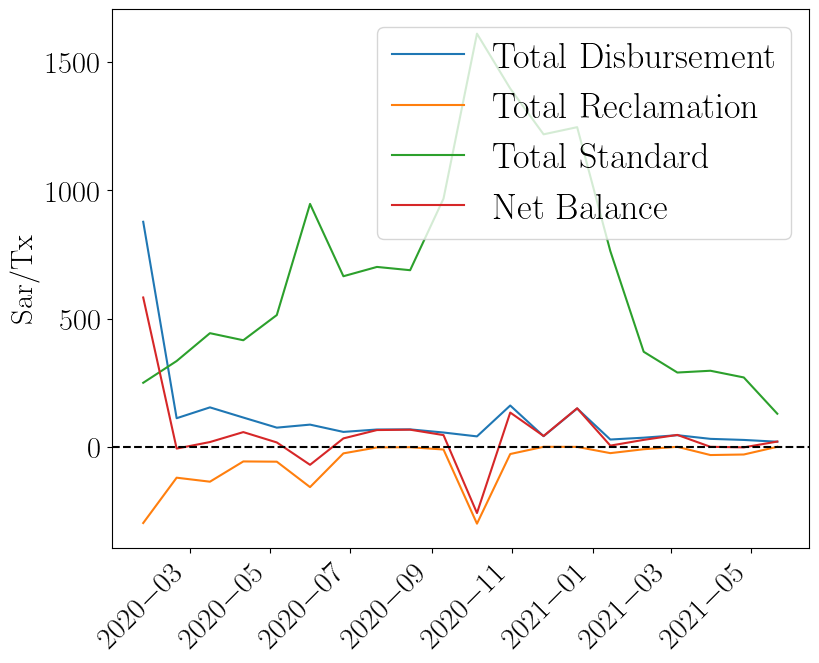

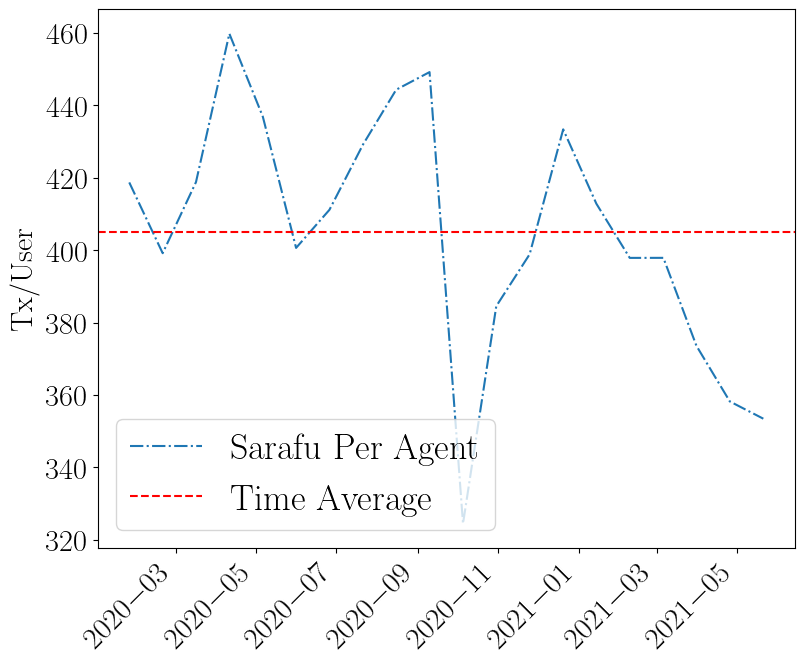

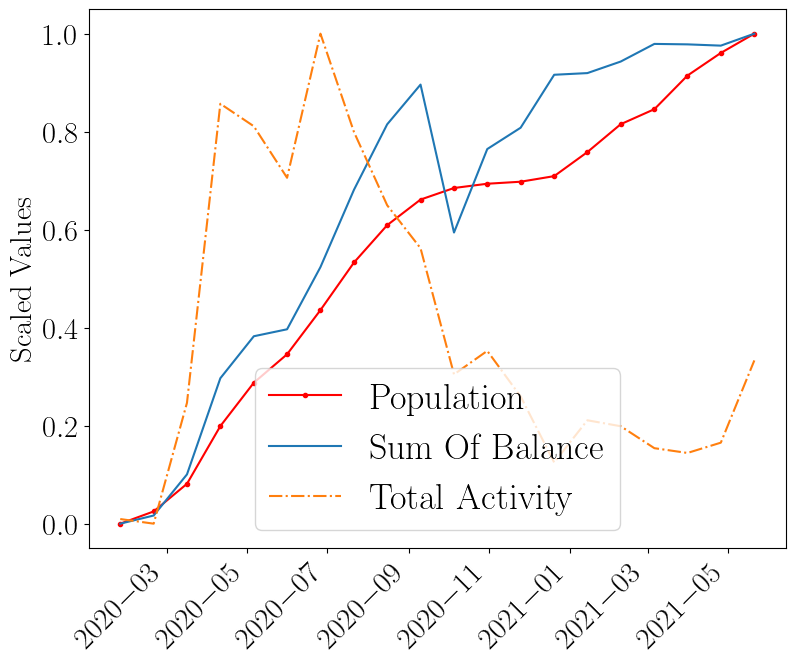

In [63]:
txns_floor = 0
bal_floor = 0

txdf = TXDF.copy(deep=True) #always do this
txdf['period'] = pd.cut(txdf.date, bins=NUM_PERIODS, labels=False) 


disb_df = txdf[disbursement(txdf)]
out_df = txdf[withdrawal(txdf)]
std_df = txdf[standard(txdf)]

bal_pre, bal_post = balance_constructor(txdf,USERS)
bal_df = bal_post.loc[(~bal_post.role.isin(['ADMIN','TOKEN_AGENT']))]
bal_pivot = pd.pivot_table(bal_df, index='crid',columns='period', values='balance', aggfunc='last')
bal_pivot = bal_pivot.ffill(axis=1)
# bal_pivot = sarafu['balance_pivot']

disb_list = [disb_df.loc[txdf.period==i]['weight'] for i in disb_df['period'].unique()]
out_list = [out_df.loc[txdf.period==i]['weight'] for i in out_df['period'].unique()]
std_list = [std_df.loc[txdf.period==i]['weight'] for i in std_df['period'].unique()]

bal_list = [bal_pivot[col].values for col in bal_pivot.columns]



disb_sum = np.array([np.sum(np.where(~np.isnan(sample),sample,0)) for sample in disb_list])
out_sum = np.array([np.sum(np.where(~np.isnan(sample),sample,0)) for sample in out_list])
std_sum = np.array([np.sum(np.where(~np.isnan(sample),sample,0)) for sample in std_list])
bal_sum = np.array([np.sum(np.where(~np.isnan(sample),sample,0)) for sample in bal_list])
bal_sum_0 = bal_pre.loc[(~bal_pre.role.isin(['ADMIN','TOKEN_AGENT']))].groupby('crid').balance.first().sum()
net = bal_sum_0 + disb_sum - out_sum 
population = bal_pivot.count()
total_activity = std_df.groupby('period').weight.count()
calc_bal_sum = disb_sum - out_sum

period_to_date = txdf.groupby('period')['date'].min()  # Get start date for each period
dates = period_to_date.sort_index().values  # Ensure chronological order



In [ ]:

# #first plot
# fig = plt.figure(figsize=(W,H))
# plt.plot(dates,disb_sum,label='total disbursement'.title())
# plt.plot(dates,-out_sum, label = 'total reclamation'.title())
# plt.plot(dates,std_sum, label = 'total standard'.title())
# plt.plot(dates,net, label = 'net balance'.title())
# plt.plot(dates,bal_sum, '-.',label = 'total wealth'.title())
# plt.axhline(y=0, color='k', linestyle='--')
# plt.axhline(y=bal_sum_0, color='k', linestyle='--')
# plt.xticks(rotation=45, ha='right')
# plt.ylabel("Sarafu",rotation = 0,labelpad=20)
# plt.legend()

# fig.savefig(FIGURES / f'flows.pdf',format = 'pdf')

# #second plot
# fig = plt.figure(figsize=(W,H))
# plt.plot(dates,disb_sum/total_activity,label='total disbursement'.title())
# plt.plot(dates,-out_sum/total_activity, label = 'total reclamation'.title())
# plt.plot(dates,std_sum/total_activity, label = 'total standard'.title())
# plt.plot(dates,net/total_activity, label = 'net balance'.title())

# plt.axhline(y=0, color='k', linestyle='--')
# plt.xticks(rotation=45, ha='right')

# plt.ylabel('Sar/Tx')
# plt.legend()
# fig.savefig(FIGURES / f'flows-per-tx.pdf',format = 'pdf')


# #third plots
# fig = plt.figure(figsize=(W,H))
# plt.plot(dates,bal_sum/population, '-.',label = 'Sarafu per agent'.title())
# plt.axhline(y=np.mean(bal_sum/population), color='r', linestyle='--',label ='time average'.title())
# plt.xticks(rotation=45, ha='right')
# plt.ylabel('Tx/User')
# plt.legend()
# fig.savefig(FIGURES / f'sarafu-per-user.pdf',format = 'pdf')



# fig = plt.figure(figsize=(W,H))
# plt.plot(dates,scale_vect(population),'r.-', label = 'population'.title())
# plt.plot(dates,scale_vect(bal_sum), label = 'sum of balance'.title())
# plt.plot(dates,scale_vect(total_activity), '-.',label = 'total activity'.title())
# # plt.xlabel()
# plt.ylabel('Scaled Values')
# plt.xticks(rotation=45, ha='right')
# plt.legend()
# fig.savefig(FIGURES / f'scaled-sizes.pdf',
#             format='pdf',
#             # bbox_inches='tight'
#             )




In [78]:
import matplotlib.pyplot as plt
print("savefig.bbox =", plt.rcParams.get("savefig.bbox"))
print("savefig.pad_inches =", plt.rcParams.get("savefig.pad_inches"))


savefig.bbox = None
savefig.pad_inches = 0.1


In [79]:
from mpl_toolkits.axes_grid1 import Divider, Size
import matplotlib.pyplot as plt

def fixed_axes(ax_w=9, ax_h=7, margins=(1.0, 1.0, 0.7, 0.3)):  
    """
    Crea una figura con assi di dimensione fissa in pollici.
    margins = (left, right, bottom, top) in pollici.
    """
    # dimensioni totali figura = area assi + margini
    fig_w = ax_w + margins[0] + margins[1]
    fig_h = ax_h + margins[2] + margins[3]

    fig = plt.figure(figsize=(fig_w, fig_h))
    divider = Divider(
        fig, (0, 0, 1, 1),
        horizontal=[Size.Fixed(margins[0]), Size.Fixed(ax_w), Size.Fixed(margins[1])],
        vertical=[Size.Fixed(margins[2]), Size.Fixed(ax_h), Size.Fixed(margins[3])]
    )

    ax = fig.add_axes(divider.get_position(), axes_locator=divider.new_locator(nx=1, ny=1))
    return fig, ax

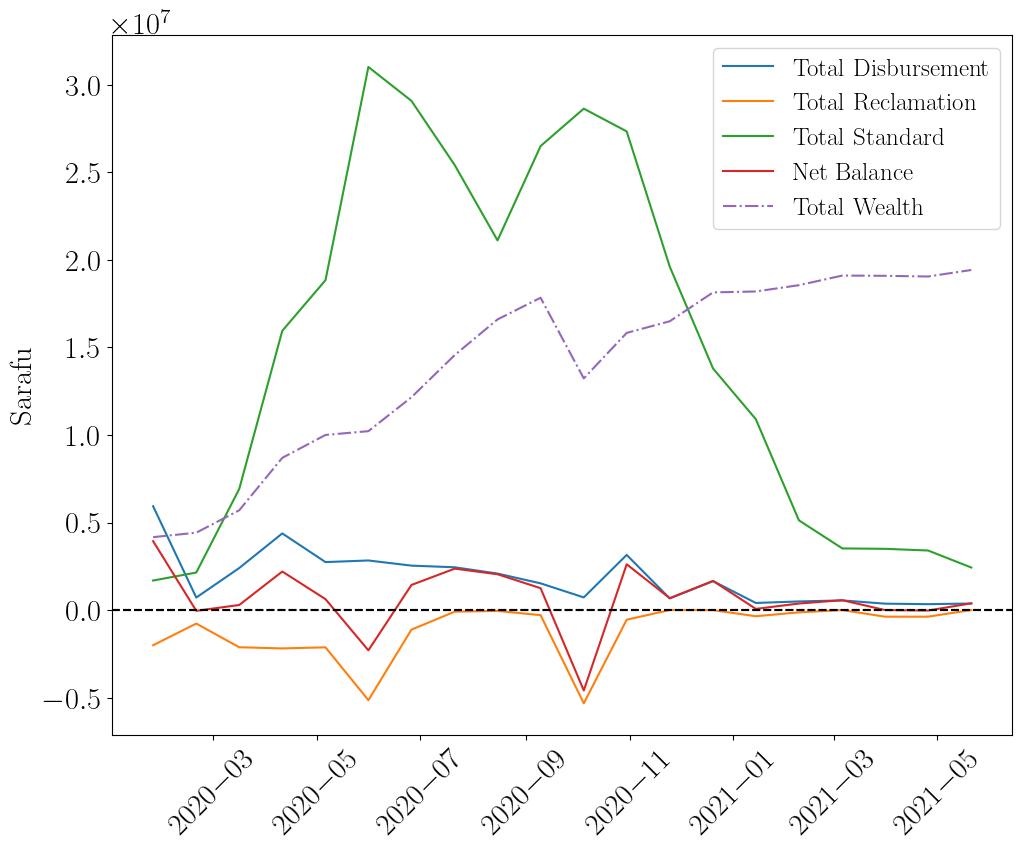

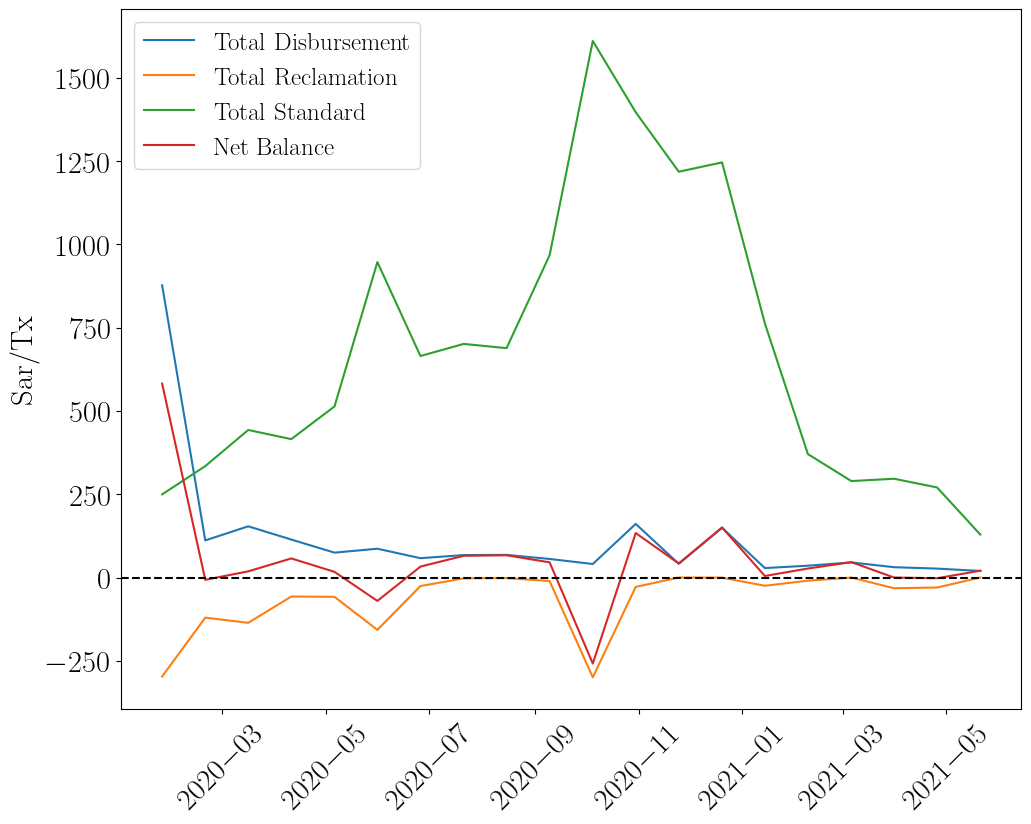

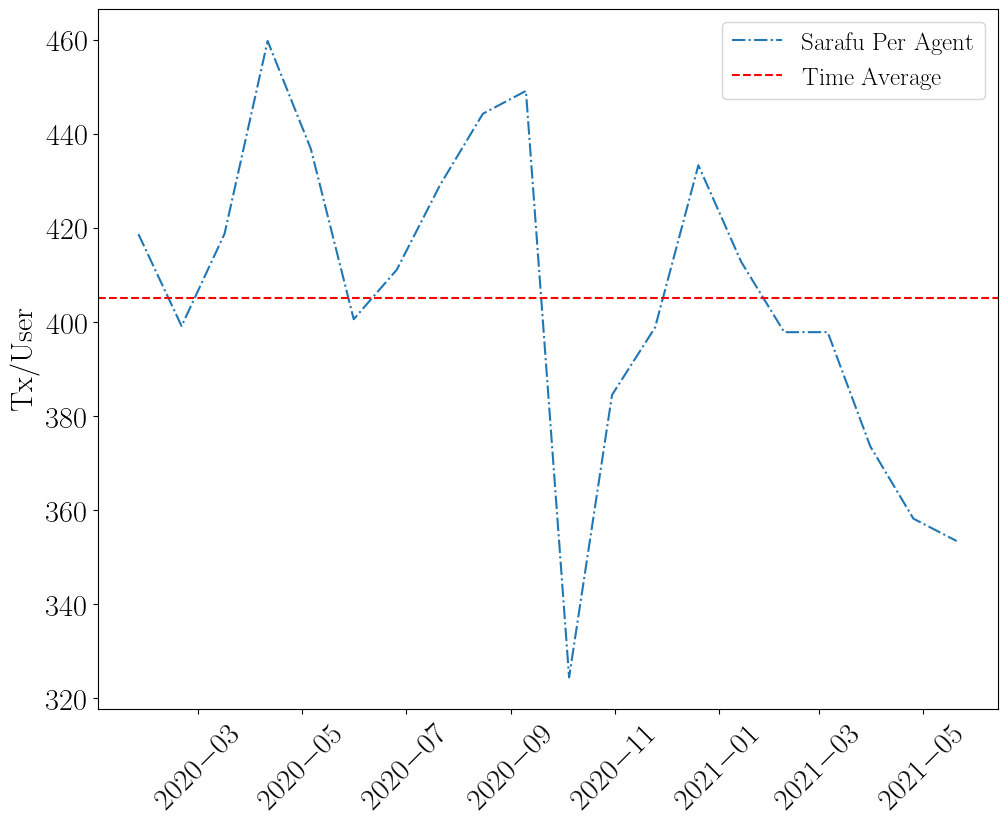

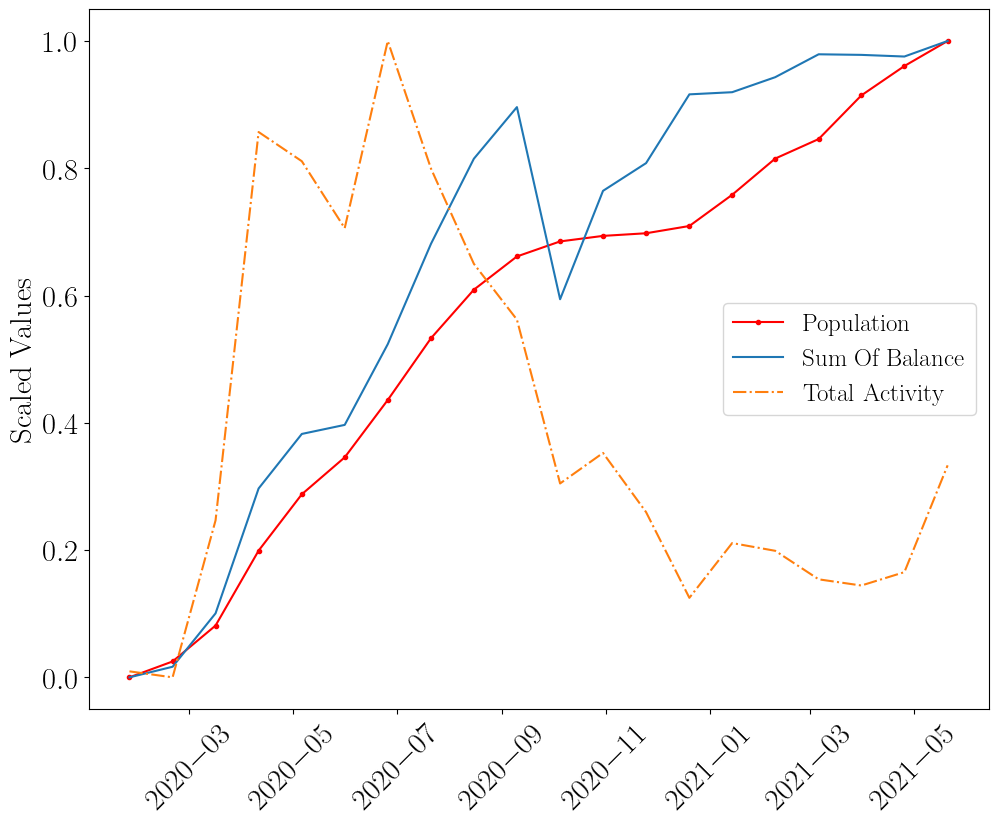

In [95]:
# Assumes: W, H, dates, disb_sum, out_sum, std_sum, net, bal_sum, bal_sum_0,
#          total_activity, population, scale_vect, FIGURES are defined.

# Fixed axes box (identical across all figures)
# [left, bottom, width, height] in figure (0..1) coordinates
L, B, WW, HH = 0.18, 0.18, 0.75, 0.72

# -----------------------
# first plot: flows
# -----------------------
# fig,ax = fixed_axes(ax_w=9, ax_h=7, margins=(1.0, 1.0, 0.7, 0.3))
fig, ax = fixed_axes(ax_w=9, ax_h=7, margins=(1.2, 1.2, 1.2, 0.6))

# fig = plt.figure(figsize=(W, H))
# ax = fig.add_axes([L, B, WW, HH])

ax.plot(dates, disb_sum, label='Total Disbursement')
ax.plot(dates, -out_sum, label='Total Reclamation')
ax.plot(dates, std_sum, label='Total Standard')
ax.plot(dates, net, label='Net Balance')
ax.plot(dates, bal_sum, '-.', label='Total Wealth')

ax.axhline(y=0, color='k', linestyle='--')
ax.axhline(y=bal_sum_0, color='k', linestyle='--')

ax.tick_params(axis='x', rotation=45)
ax.set_ylabel("Sarafu")
ax.legend(prop={"size": 18})

fig.savefig(FIGURES / "flows.pdf", format="pdf",bbox_inches=None, pad_inches =0.0 )
# plt.close(fig)

# -----------------------
# second plot: flows per tx
# -----------------------
# fig,ax = fixed_axes(ax_w=9, ax_h=7, margins=(1.0, 1.0, 0.7, 0.3))
fig, ax = fixed_axes(ax_w=9, ax_h=7, margins=(1.2, 1.2, 1.2, 0.6))

# fig = plt.figure(figsize=(W, H))
# ax = fig.add_axes([L, B, WW, HH])

ax.plot(dates, disb_sum / total_activity, label='Total Disbursement')
ax.plot(dates, -out_sum / total_activity, label='Total Reclamation')
ax.plot(dates, std_sum / total_activity, label='Total Standard')
ax.plot(dates, net / total_activity, label='Net Balance')

ax.axhline(y=0, color='k', linestyle='--')

ax.tick_params(axis='x', rotation=45)
ax.set_ylabel("Sar/Tx")
ax.legend(prop={"size": 18})

fig.savefig(FIGURES / "flows-per-tx.pdf", format="pdf",bbox_inches=None, pad_inches =0.0)
# plt.close(fig)

# -----------------------
# third plot: sarafu per user
# -----------------------
# fig,ax = fixed_axes(ax_w=9, ax_h=7, margins=(1.0, 1.0, 0.7, 0.3))
fig, ax = fixed_axes(ax_w=9, ax_h=7, margins=(1.2, 1.2, 1.2, 0.6))

# fig = plt.figure(figsize=(W, H))
# ax = fig.add_axes([L, B, WW, HH])

y = bal_sum / population
ax.plot(dates, y, '-.', label='Sarafu Per Agent')
ax.axhline(y=float(np.mean(y)), color='r', linestyle='--', label='Time Average')

ax.tick_params(axis='x', rotation=45)
ax.set_ylabel("Tx/User")
ax.legend(prop={"size": 18})

fig.savefig(FIGURES / "sarafu-per-user.pdf", format="pdf",bbox_inches=None, pad_inches =0.0 )
# plt.close(fig)

# -----------------------
# fourth plot: scaled sizes
# -----------------------
# fig,ax = fixed_axes(ax_w=9, ax_h=7, margins=(1.0, 1.0, 0.7, 0.3))
fig, ax = fixed_axes(ax_w=9, ax_h=7, margins=(1.2, 1.2, 1.2, 0.6))

# fig = plt.figure(figsize=(W, H))
# ax = fig.add_axes([L, B, WW, HH])

ax.plot(dates, scale_vect(population), 'r.-', label='Population')
ax.plot(dates, scale_vect(bal_sum), label='Sum Of Balance')
ax.plot(dates, scale_vect(total_activity), '-.', label='Total Activity')

ax.tick_params(axis='x', rotation=45)
ax.set_ylabel("Scaled Values")
ax.legend(prop={"size": 18})

fig.savefig(FIGURES / "scaled-sizes.pdf", format="pdf",bbox_inches=None, pad_inches =0.0 )
# plt.close(fig)


In [70]:
[f for f in os.listdir(FIGURES) if "txtype" in f and "2x2" not in f]

['txtype_RECLAMATION.pdf',
 'txtype_STANDARD.pdf',
 'txtype_DISBURSEMENT.pdf',
 'txtype_AGENT_OUT.pdf']

clayton [0.97591] 3880.9734852559204
gumbel [2.39263674] 12145.432734277707
frank [6.35058594] 8331.182765449115
joe [3.1477007] 15132.43844487601
galambos [1.08463795] 7440.37323027341
fgm [0.999999] 4211.976891076293
plackett [17.15575466] 9541.849074398839
rgumbel [1.86181986] 6650.591901386713
rclayton [2.83056842] 13745.193534654496
rjoe [1.00853959] 11538.227820347565
rgalambos [0.74579688] 3911.726711223224
BB1 [1.00000019e-06 2.39263425e+00] 12145.42867947288
 message: Inequality constraints incompatible
 success: False
  status: 4
     fun: nan
       x: [ 1.000e+00  1.000e+00]
     nit: 1
     jac: [       nan        nan]
    nfev: 3
    njev: 1
optimization failed
Error fitting BB2: cannot unpack non-iterable NoneType object
Best copula: joe, Parameter: [3.1477007], Score: 15132.43844487601


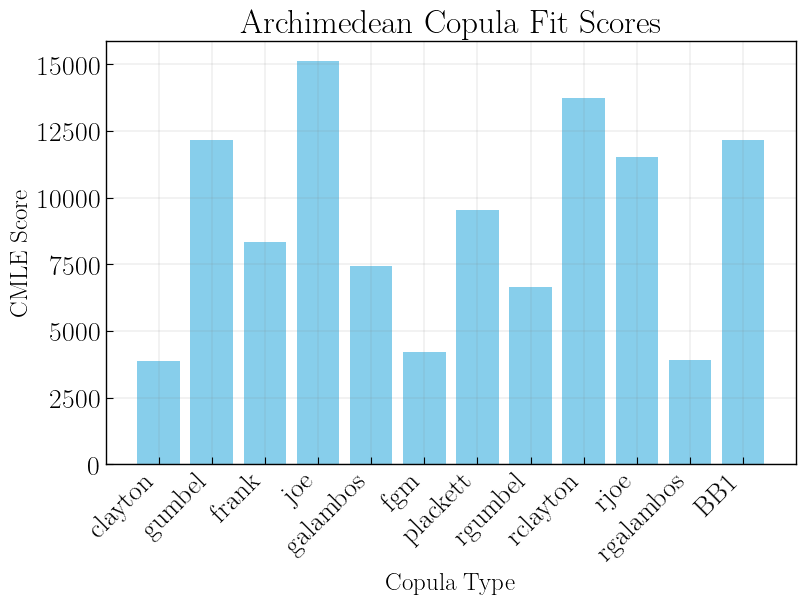

In [55]:
import matplotlib.pyplot as plt
import numpy as np
from pycop import estimation, archimedean

# Assuming 'agents' DataFrame exists
# data = agents[['activity', 'attractiveness']]
data = agents[['tx_out','tx_in']]
data = data.rank(pct=True).T.values

max_score = 0
cmles = []
copula_types = []
fitted_params = []

for copula_type in archimedean.Archimedean_families:
    try:
        cop = archimedean(copula_type)
        param, cmle = estimation.fit_cmle(cop, data)
        cmles.append(cmle)
        copula_types.append(copula_type)
        fitted_params.append(param)
                
        if cmle >= max_score:
            max_score = cmle
            winner = copula_type
            winner_param = param
        
        print(copula_type, param, cmle)
    except Exception as e:
        print(f"Error fitting {copula_type}: {e}")
        pass

    with open('sarafu_info.txt','a') as f:
        print(f'Best copula: {winner}, Parameter: {winner_param}, Score: {max_score}',file=f)

print(f'Best copula: {winner}, Parameter: {winner_param}, Score: {max_score}')

# Plot CMLE scores
fig = plt.figure()
plt.bar(copula_types, cmles, color='skyblue')
plt.xlabel('Copula Type')
plt.ylabel('CMLE Score')
plt.title('Archimedean Copula Fit Scores')
plt.xticks(rotation=45, ha='right')
plt.show()


In [ ]:
# fig.savefig(FIGURES / f'copulafit.pdf')
if save:
    fig.savefig(FIGURES / f'copulafit.pdf',bbox_inches='tight', pad_inches=0.1)

$\mathcal{R}$

# Copule

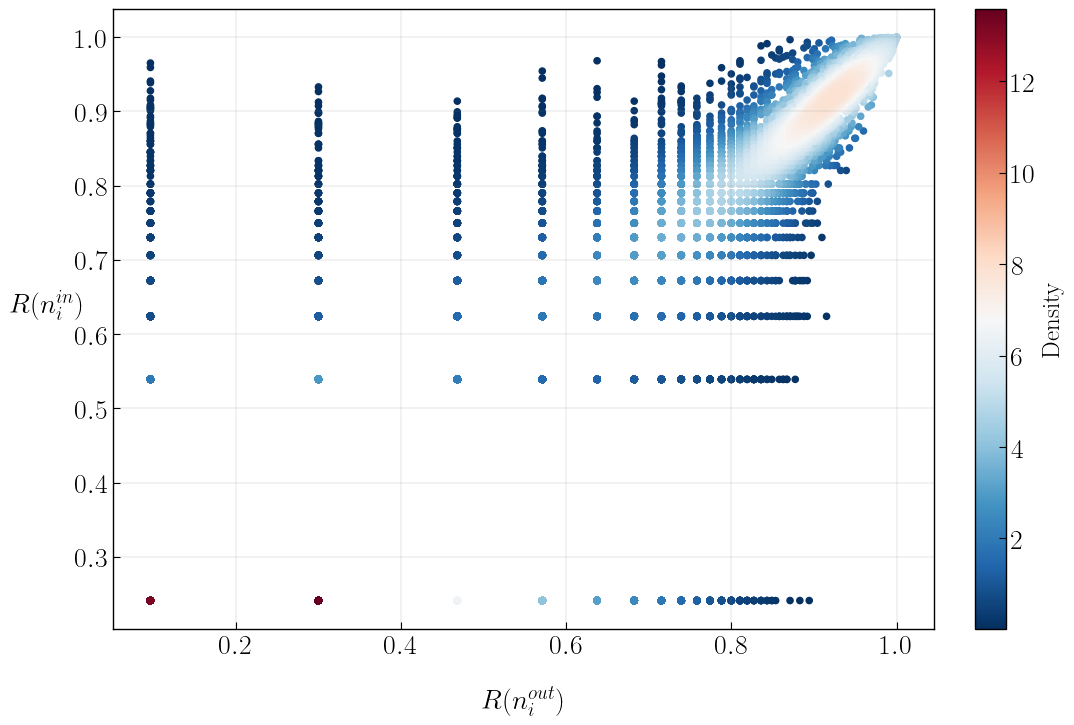

In [ ]:
data = agents[['tx_out','tx_in']]

ranked_data = data.rank(pct=True)
# ranked_data = data.rank()

fig, ax = plt.subplots(constrained_layout=True)  # Usare constrained_layout migliora la gestione dello spazio
plt.subplots_adjust(bottom=0.2,left=0.2)  # Evita il taglio delle label in basso
    
# xlabel = r'PsOb($N^{out}$)'
# ylabel = r'PsOb($N^{in})$'

xlabel = r'$R(n_i^{out})$'
ylabel = r'$R(n_i^{in})$'

plot_scatter_kde(ranked_data.values,ax,cmap='RdBu_r',s=20)
# plt.loglog()
plt.xlabel(xlabel,rotation = 0,labelpad=20,fontsize=20)
plt.ylabel(ylabel,rotation = 0,labelpad=20,fontsize=20)
set_size(1.5*B,B,ax)
# set_size(1.62*b,b,ax)
# save=1
if save:
    fig.savefig(FIGURES / f'actattr_rank.pdf', 
                # bbox_inches='tight', 
                # pad_inches=0.1,
                # bbox_extra_artists=[ax.xaxis.label, ax.yaxis.label]
                )

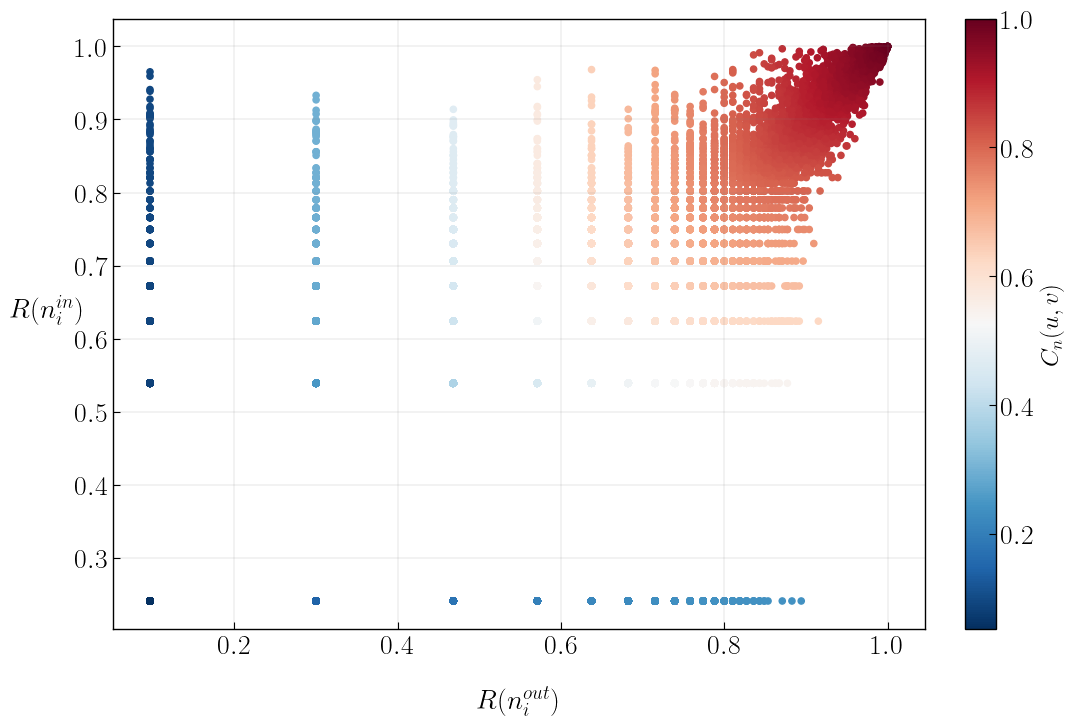

In [ ]:
x = agents.tx_out
y = agents.tx_in

# Your original data (uniform margins)
u = to_uniform(x)
v = to_uniform(y)

# Evaluation points (e.g. 100 points from 0.01 to 0.99)
u_grid = np.linspace(0.01, 0.99, 100)

# Compute empirical copula at diagonal points (u,u)
emp_copula_values = np.array([empirical_copula(u, v, u_eval, u_eval) for u_eval in u_grid])


# Compute empirical copula values at data points
emp_copula_at_data = np.array([empirical_copula(u, v, u[i], v[i]) for i in range(len(u))])

# Scatter plot
fig,ax = plt.subplots(constrained_layout=True)
plt.subplots_adjust(bottom=0.2,left=0.2)
scatter = ax.scatter(u, v, c=emp_copula_at_data, cmap='RdBu_r', s=20)
plt.xlabel(xlabel,rotation = 0,labelpad=20,fontsize=20)
plt.ylabel(ylabel,rotation = 0,labelpad=20,fontsize=20)
set_size(1.5*B,B,ax)
# plt.title('Empirical Copula Scatter Plot')
plt.colorbar(scatter, label='$C_n(u,v)$')
# plt.grid(True)
# set_size(1.62*b,b,ax)
plt.show()

if save:
    fig.savefig(FIGURES / f'actattr_rank_cdf.pdf', 
                # bbox_inches='tight', 
                # pad_inches=0.1, 
                # bbox_extra_artists=[ax.xaxis.label, ax.yaxis.label]
                )

In [ ]:
from local_utils import plot_scatter_from_kde

ImportError: cannot import name 'plot_scatter_from_kde' from 'local_utils' (/home/claudio/papers/adtxns_paper/code/thesis_nb/local_utils.py)

: 

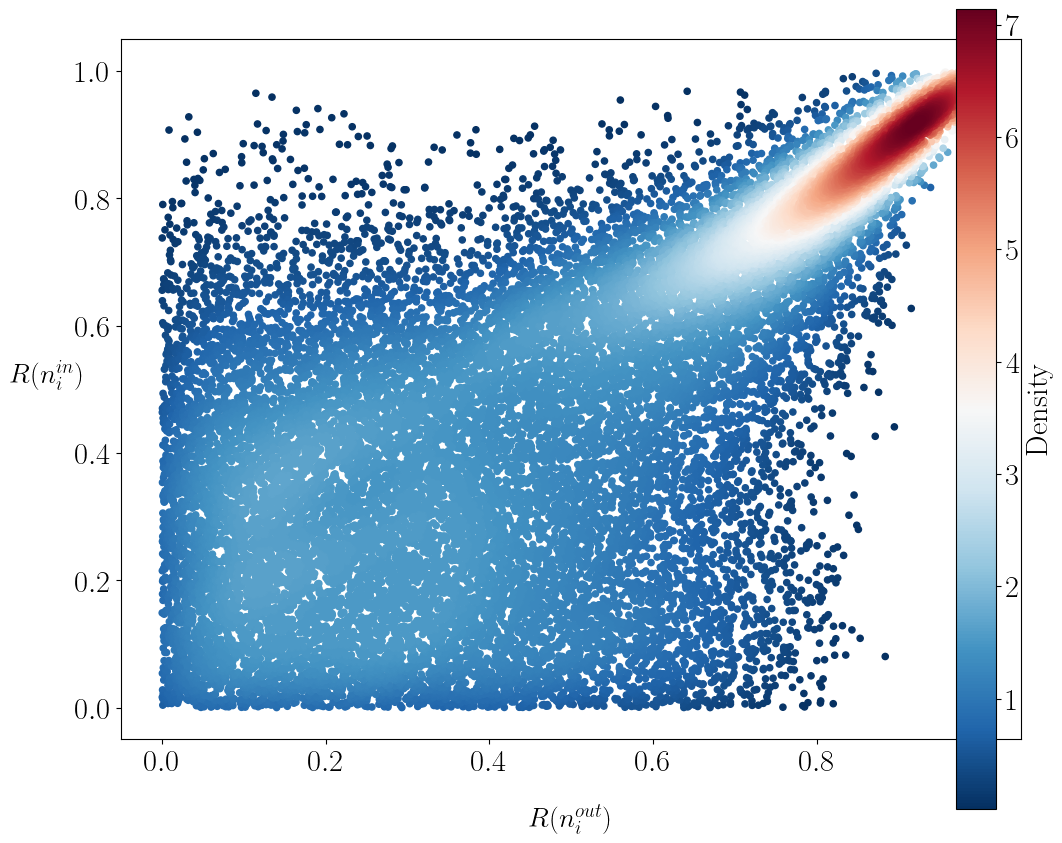

In [96]:
agents[['pertx_out','pertx_in']] = agents[['tx_out','tx_in']] + 0.5*np.random.uniform(0,1,(agents.shape[0],2))
data = agents[['pertx_out','pertx_in']]


xlabel = r'$R(n_i^{out})$'
ylabel = r'$R(n_i^{in})$'

ranked_data = data.rank(pct=True)
# ranked_data = data.rank()

# fig,ax = plt.subplots(constrained_layout=True)
# plt.subplots_adjust(bottom=0.2,left=0.2)
fig,ax=fixed_axes(ax_w=9, ax_h=7, margins=(1.0, 1.0, 0.7, 0.3))
# xlabel = r'PsOb($N^{out}$)'
# ylabel = r'PsOb($N^{in})$'

plot_scatter_kde(ranked_data.values,ax,cmap='RdBu_r',s=20)
# plt.loglog()
plt.xlabel(xlabel,rotation = 0,labelpad=20,fontsize=20)
plt.ylabel(ylabel,rotation = 0,labelpad=20,fontsize=20)
# set_size(1.5*B,B,ax)


if save:
    fig.savefig(FIGURES / f'actattr_rank_pert.pdf', 
                bbox_inches='tight', 
                # pad_inches=0.1, 
                # bbox_extra_artists=[ax.xaxis.label, ax.yaxis.label]
                )

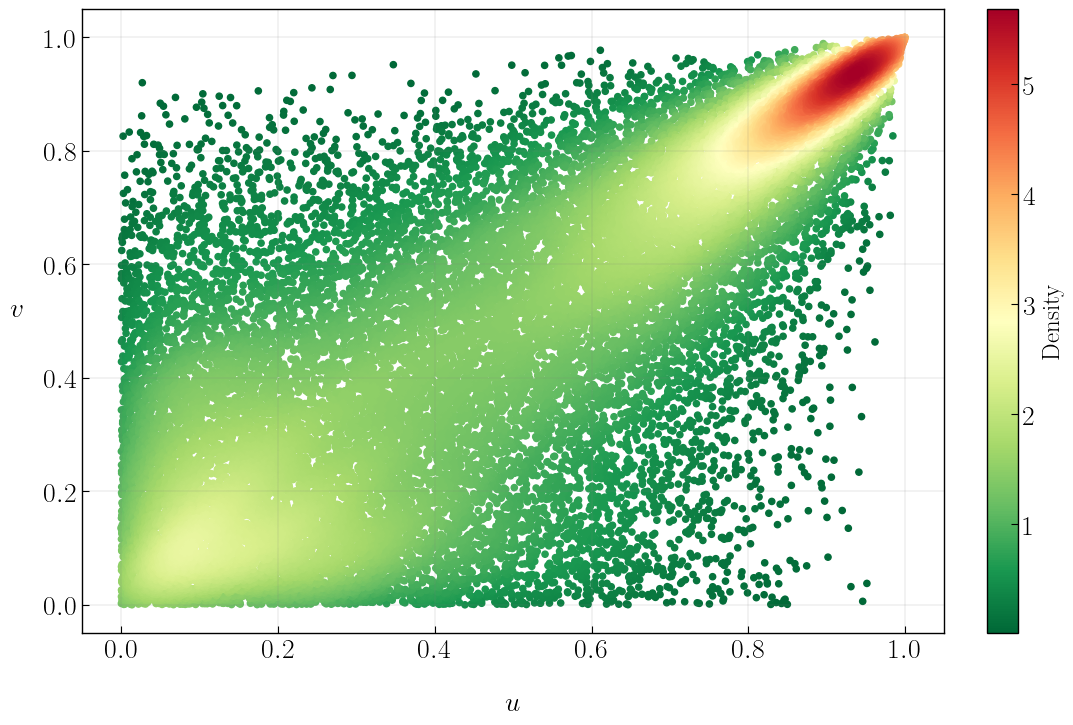

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pycop.simulation import simu_archimedean

# Define the best copula and parameter found from the previous script
best_copula_type = winner  # Ensure 'winner' is set from the previous script
best_param = winner_param  # Ensure 'winner_param' is set from the previous script

# Initialize the copula
size = agents.shape[0]
u,v = simu_archimedean(best_copula_type, 2,size,theta=best_param[0])

# Plot the generated sample
fig,ax = plt.subplots(constrained_layout=True)
plt.subplots_adjust(bottom=0.2,left=0.2)
plot_scatter_kde(np.column_stack((u, v)),ax=ax,cmap='RdYlGn_r', s=20)
plt.xlabel('$u$',rotation = 0,labelpad=20,fontsize=20)
plt.ylabel('$v$',rotation = 0,labelpad=20,fontsize=20)

set_size(1.5*B,B,ax)
plt.show()

# # If needed, store the sample in a variable for further analysis
# synthetic_data = sample
if save:
    fig.savefig(FIGURES / f'copulafit_sample.pdf', 
                # bbox_inches='tight', 
                # pad_inches=0.1, 
                # bbox_extra_artists=[ax.xaxis.label, ax.yaxis.label]
                )

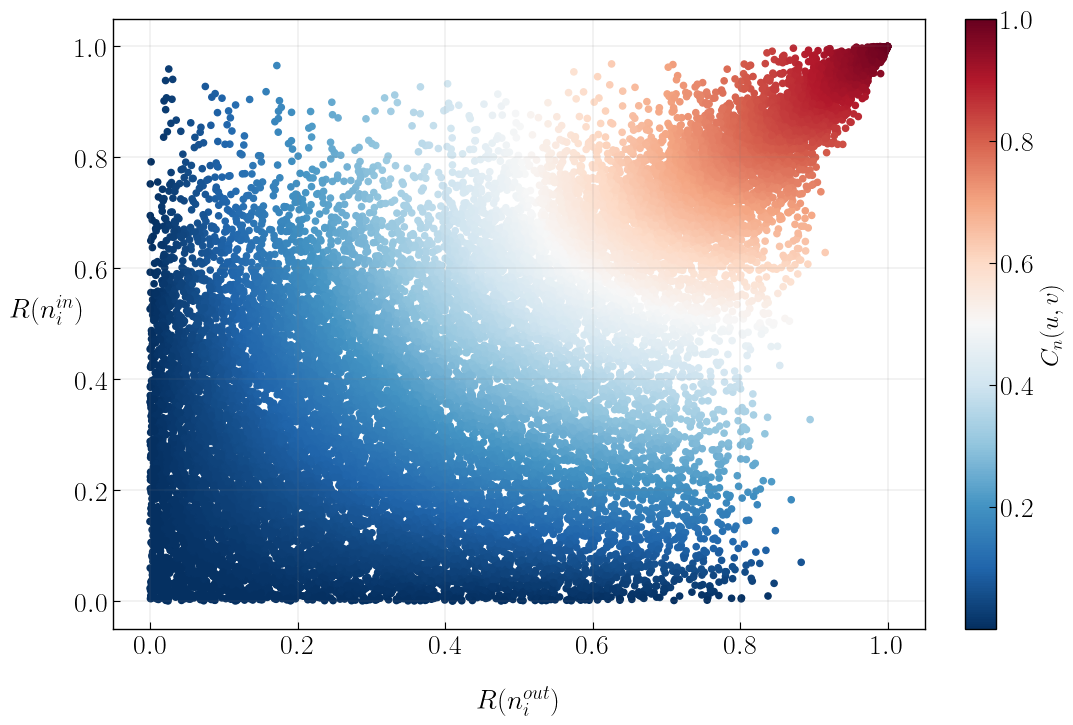

In [ ]:
x = agents.pertx_out
y = agents.pertx_in

# Your original data (uniform margins)
u = to_uniform(x)
v = to_uniform(y)

# Evaluation points (e.g. 100 points from 0.01 to 0.99)
u_grid = np.linspace(0.01, 0.99, 100)

# Compute empirical copula at diagonal points (u,u)
emp_copula_values = np.array([empirical_copula(u, v, u_eval, u_eval) for u_eval in u_grid])


# Compute empirical copula values at data points
emp_copula_at_data = np.array([empirical_copula(u, v, u[i], v[i]) for i in range(len(u))])

# Scatter plot
# fig,ax = plt.subplots()
fig,ax = plt.subplots(constrained_layout=True)
plt.subplots_adjust(bottom=0.2,left=0.2)
scatter = ax.scatter(u, v, c=emp_copula_at_data, cmap='RdBu_r', s=20)
plt.xlabel(xlabel,rotation = 0,labelpad=20,fontsize=20)
plt.ylabel(ylabel,rotation = 0,labelpad=20,fontsize=20)

# plt.title('Empirical Copula Scatter Plot')
plt.colorbar(scatter, label='$C_n(u,v)$')
# plt.grid(True)

set_size(1.5*B,B,ax)

plt.show()
if save:
    # fig.savefig(FIGURES / f'actattr_rank_cdf_pert.pdf',bbox_inches='tight', pad_inches=0.1)
    fig.savefig(FIGURES / f'actattr_rank_cdf_pert.pdf',
                # bbox_inches='tight', 
                # pad_inches=0.1,
                # bbox_extra_artists=[ax.xaxis.label, ax.yaxis.label]
                )


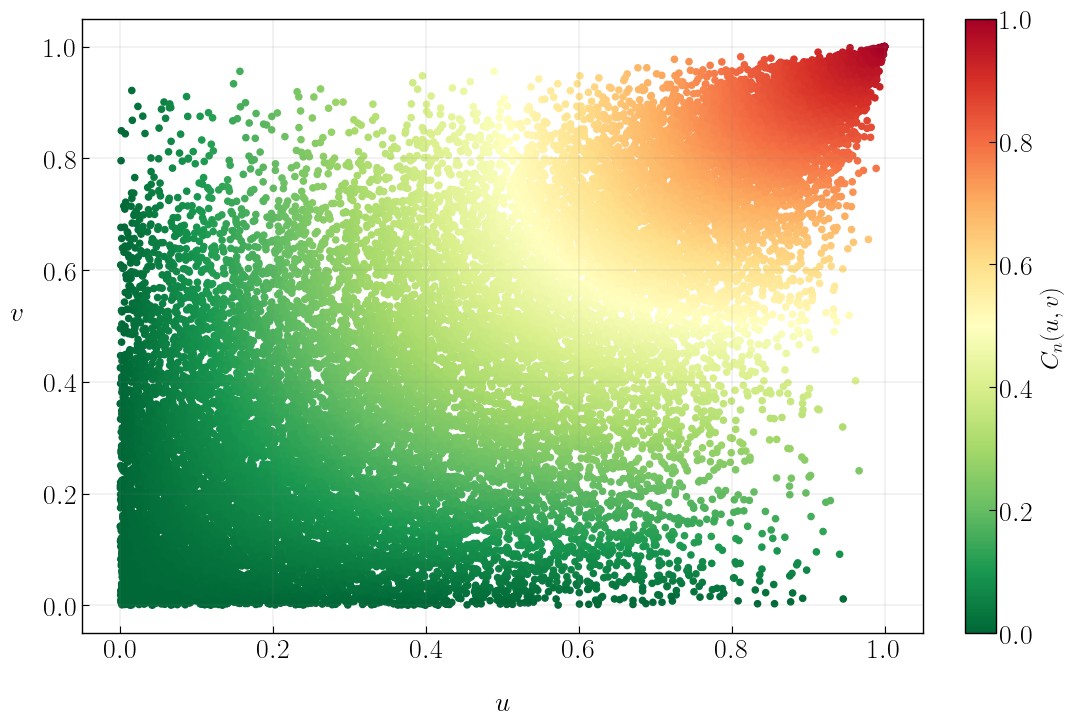

In [ ]:
# x = samples.tx_out
# y = samples.tx_in

# # Your original data (uniform margins)
# u = to_uniform(x)
# v = to_uniform(y)
u,v = simu_archimedean(best_copula_type, 2,size,theta=best_param[0])

# Evaluation points (e.g. 100 points from 0.01 to 0.99)
u_grid = np.linspace(0.01, 0.99, 100)

# Compute empirical copula at diagonal points (u,u)
emp_copula_values = np.array([empirical_copula(u, v, u_eval, u_eval) for u_eval in u_grid])


# Compute empirical copula values at data points
emp_copula_at_data = np.array([empirical_copula(u, v, u[i], v[i]) for i in range(len(u))])

# Scatter plot
fig,ax = plt.subplots(constrained_layout=True)
plt.subplots_adjust(bottom=0.2,left=0.2)
scatter = ax.scatter(u, v, c=emp_copula_at_data, cmap='RdYlGn_r', s=20)
plt.xlabel('$u$',rotation = 0,labelpad=20,fontsize=20)
plt.ylabel('$v$',rotation = 0,labelpad=20,fontsize=20)
# plt.title('Empirical Copula Scatter Plot')
plt.colorbar(scatter, label='$C_n(u,v)$')
# plt.grid(True)

set_size(1.5*B,B,ax)

plt.show()

if save:
    # fig.savefig(FIGURES / f'copulafit_sample_cdf.pdf',bbox_inches='tight', pad_inches=0.1)
    fig.savefig(FIGURES / f'copulafit_sample_cdf.pdf', 
                # bbox_inches='tight', 
                # pad_inches=0.1, 
                # bbox_extra_artists=[ax.xaxis.label, ax.yaxis.label]
                )


In [63]:
for method in ['kendall', 'spearman', 'pearson']:
    print(method, agents[['tx_out','tx_in']].corr(method=method))


kendall           tx_out     tx_in
tx_out  1.000000  0.623467
tx_in   0.623467  1.000000
spearman          tx_out    tx_in
tx_out  1.00000  0.72741
tx_in   0.72741  1.00000
pearson           tx_out     tx_in
tx_out  1.000000  0.892263
tx_in   0.892263  1.000000


In [64]:
# labels
samples = pd.DataFrame({'u':u,
                       'v':v, 
                       columns[0]:powlaw_ppf(fits[columns[0]]['alpha'],fits[columns[0]]['xmin'],fits[columns[0]]['xmax'])(u), 
                       columns[1]:powlaw_ppf(fits[columns[1]]['alpha'],fits[columns[1]]['xmin'],fits[columns[1]]['xmax'])(v)})

In [65]:
T = (tx.date.max() - tx.date.min()).total_seconds()

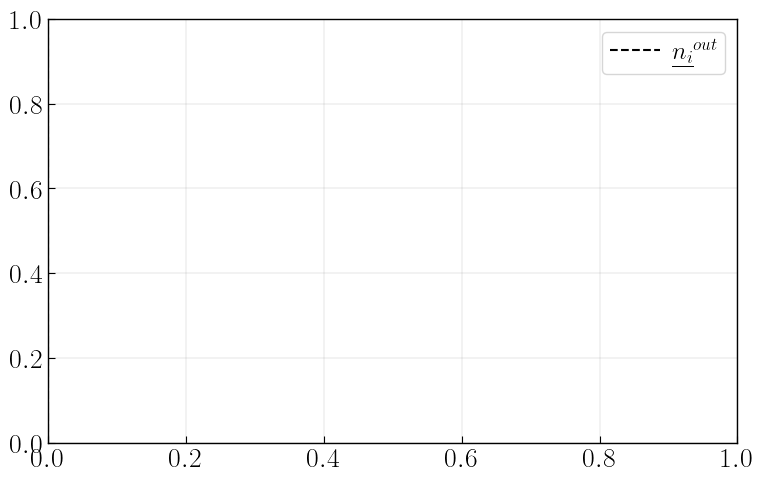

In [66]:
plt.axvline(x=0, color='k', linestyle='--', label=r'$\underline{n_i}^{out}$')
plt.legend()


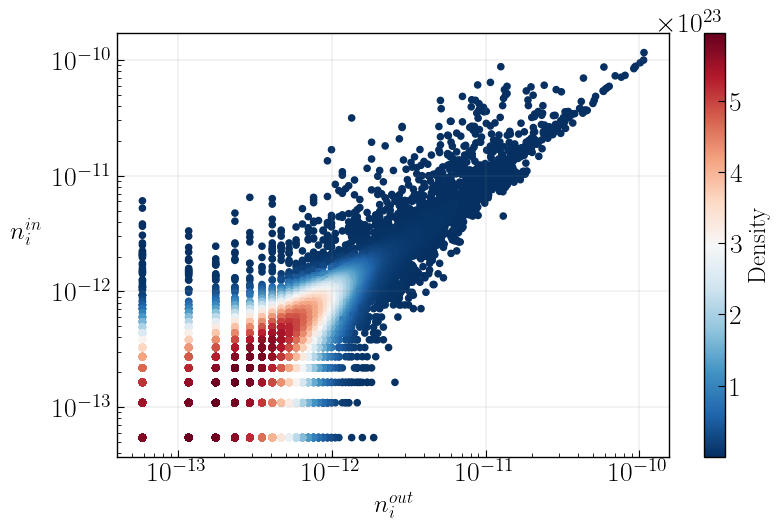

In [ ]:
# data = agents[['tx_out','tx_in']].values
agents['norm_tx_out'] = agents.tx_out/agents.tx_out.sum()/T
agents['norm_tx_in'] = agents.tx_in/agents.tx_in.sum()/T
data = agents[['norm_tx_out','norm_tx_in']].values

fig,ax=plt.subplots()
xlabel = r'$n_i^{out}$'
ylabel = r'$n_i^{in}$'

plot_scatter_kde(data,ax,cmap='RdBu_r',s=20)
plt.loglog()
plt.xlabel(xlabel)
plt.ylabel(ylabel,rotation = 0,labelpad=20)

if save:
    fig.savefig(FIGURES / f'normalized_actattr_rates_corr.pdf',bbox_inches='tight', pad_inches=0.1)


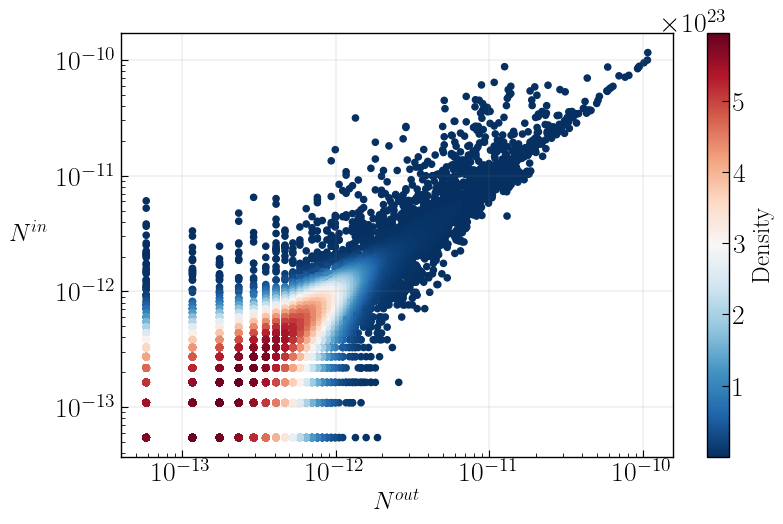

In [ ]:
# data = agents[['tx_out','tx_in']].values
agents['norm_tx_out'] = agents.tx_out/agents.tx_out.sum()/T
agents['norm_tx_in'] = agents.tx_in/agents.tx_in.sum()/T
data = agents[['norm_tx_out','norm_tx_in']].values

fig,ax=plt.subplots()
xlabel = r'$N^{out}$'
ylabel = r'$N^{in}$'

plot_scatter_kde(data,ax,cmap='RdBu_r',s=20)
plt.loglog()
plt.xlabel(xlabel)
plt.ylabel(ylabel,rotation = 0,labelpad=20)

if save:
    fig.savefig(FIGURES / f'normalized_actattr_rates_corr.pdf',bbox_inches='tight', pad_inches=0.1)


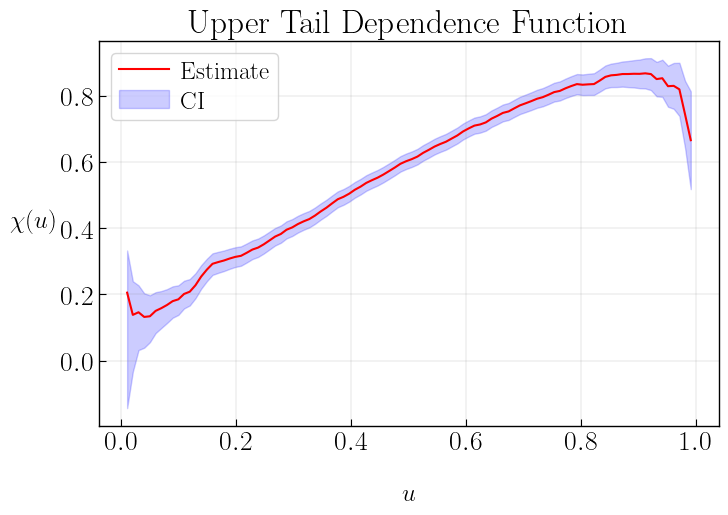

In [69]:
import numpy as np
import scipy.stats as st
import matplotlib.pyplot as plt

def empirical_extremal_function(data, link_formula, survival=False, conf_level=0.95, points=100):
    n = len(data)
    ranks = (st.rankdata(data, axis=0)) / (n + 1)
    u_grid = np.linspace(1/(points+1), points/(points+1), points)
    
    values = np.zeros(points)
    ci_low = np.zeros(points)
    ci_up = np.zeros(points)
    
    z = st.norm.ppf(0.5 + 0.5 * conf_level)
    
    for i, u in enumerate(u_grid):
        if survival:
            cuu = np.mean((u < np.minimum(ranks[:, 0], ranks[:, 1])))
        else:
            cuu = np.mean((u > np.maximum(ranks[:, 0], ranks[:, 1])))

        # Adjust cuu to avoid log issues
        epsilon = np.finfo(float).eps
        cuu = np.clip(cuu, epsilon, 1 - epsilon)

        # Estimate
        values[i] = link_formula(u, cuu)

        # Confidence interval for cuu
        se = np.sqrt(cuu * (1 - cuu) / n)
        lb = cuu - z * se
        ub = cuu + z * se
        lb = np.clip(lb, epsilon, 1 - epsilon)
        ub = np.clip(ub, epsilon, 1 - epsilon)

        # CI for function
        ci_low[i] = np.clip(link_formula(u, lb), -1, 1)
        ci_up[i] = np.clip(link_formula(u, ub), -1, 1)

    return u_grid, values, ci_low, ci_up

# Link formulas translated to Python
def chi(u, cuu):
    return 2 - np.log(cuu) / np.log(u)

def chi_bar(u, cuu):
    return 2 * np.log(1 - u) / np.log(cuu) - 1

def chi_L(u, cuu):
    return np.log(1 - cuu) / np.log(1 - u)

def chi_bar_L(u, cuu):
    return 2 * np.log(u) / np.log(cuu) - 1

# Interface functions for clarity
def draw_upper_tail(data):
    return empirical_extremal_function(data, chi, survival=False)

def draw_upper_extremal(data):
    return empirical_extremal_function(data, chi_bar, survival=True)

def draw_lower_tail(data):
    return empirical_extremal_function(data, chi_L, survival=False)

def draw_lower_extremal(data):
    return empirical_extremal_function(data, chi_bar_L, survival=False)

# Example usage (assuming your data is available as x,y):
data = agents[['pertx_out','pertx_in']].values
# data=agents[['tx_out','tx_in']].values

u, val, low, up = draw_upper_tail(data)

# Example plotting
plt.figure(figsize=(8, 5))
plt.plot(u, val, label='Estimate', color='red')
plt.fill_between(u, low, up, color='blue', alpha=0.2, label='CI')
plt.xlabel('$u$',rotation = 0,labelpad=20)
plt.ylabel('$\\chi(u)$',rotation = 0,labelpad=20)
plt.title('Upper Tail Dependence Function')
# plt.grid()
plt.legend()
plt.show()


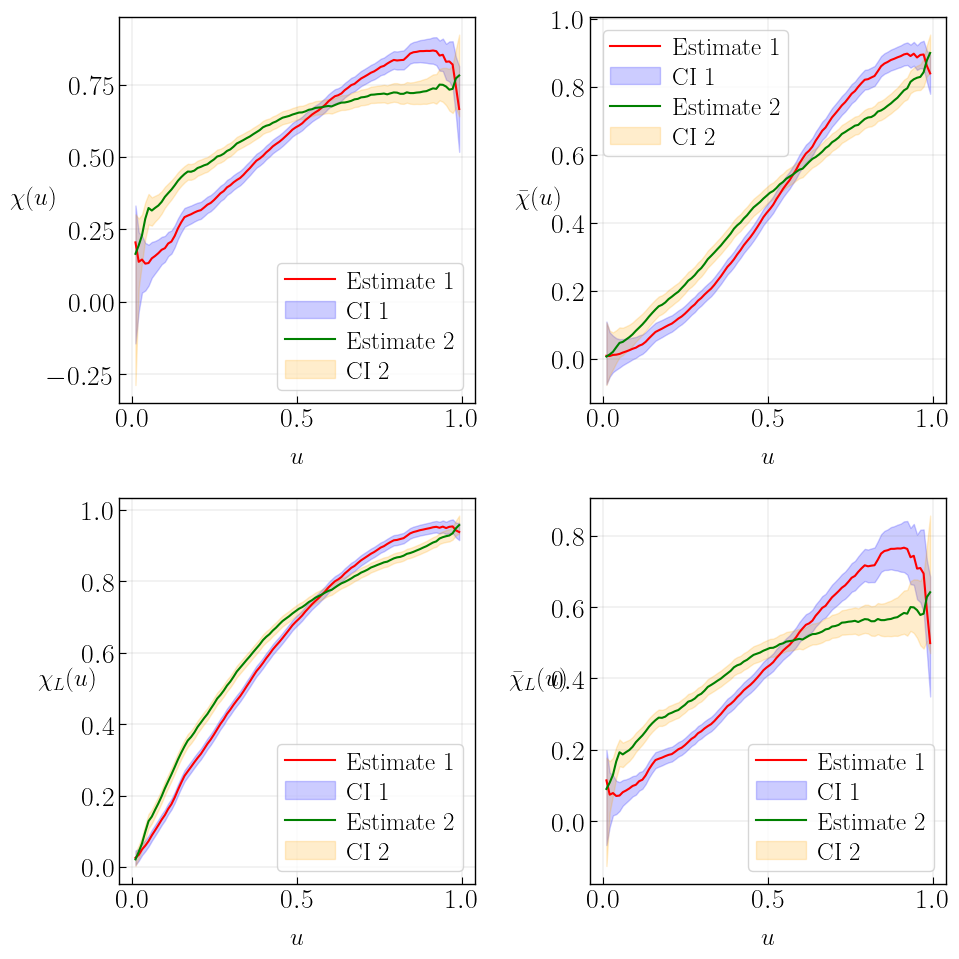

In [70]:
import numpy as np
import scipy.stats as st
import matplotlib.pyplot as plt

def empirical_extremal_function(data, link_formula, survival=False, conf_level=0.95, points=100):
    n = len(data)
    ranks = (st.rankdata(data, axis=0)) / (n + 1)
    u_grid = np.linspace(1/(points+1), points/(points+1), points)
    
    values = np.zeros(points)
    ci_low = np.zeros(points)
    ci_up = np.zeros(points)
    
    z = st.norm.ppf(0.5 + 0.5 * conf_level)
    
    for i, u in enumerate(u_grid):
        if survival:
            cuu = np.mean((u < np.minimum(ranks[:, 0], ranks[:, 1])))
        else:
            cuu = np.mean((u > np.maximum(ranks[:, 0], ranks[:, 1])))

        epsilon = np.finfo(float).eps
        cuu = np.clip(cuu, epsilon, 1 - epsilon)
        
        values[i] = link_formula(u, cuu)
        
        se = np.sqrt(cuu * (1 - cuu) / n)
        lb = np.clip(cuu - z * se, epsilon, 1 - epsilon)
        ub = np.clip(cuu + z * se, epsilon, 1 - epsilon)
        
        ci_low[i] = np.clip(link_formula(u, lb), -1, 1)
        ci_up[i] = np.clip(link_formula(u, ub), -1, 1)
    
    return u_grid, values, ci_low, ci_up

def chi(u, cuu):
    return 2 - np.log(cuu) / np.log(u)

def chi_bar(u, cuu):
    return 2 * np.log(1 - u) / np.log(cuu) - 1

def chi_L(u, cuu):
    return np.log(1 - cuu) / np.log(1 - u)

def chi_bar_L(u, cuu):
    return 2 * np.log(u) / np.log(cuu) - 1

def draw_upper_tail(data):
    return empirical_extremal_function(data, chi, survival=False)

def draw_upper_extremal(data):
    return empirical_extremal_function(data, chi_bar, survival=True)

def draw_lower_tail(data):
    return empirical_extremal_function(data, chi_L, survival=False)

def draw_lower_extremal(data):
    return empirical_extremal_function(data, chi_bar_L, survival=False)

# Example usage:
data1 = agents[['pertx_out', 'pertx_in']].values
data2 = samples[['u','v']].values

functions = [draw_upper_tail, draw_upper_extremal, draw_lower_tail, draw_lower_extremal]
labels = [r'$\chi(u)$', r'$\bar{\chi}(u)$', r'$\chi_L(u)$', r'$\bar{\chi}_L(u)$']

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
for ax, func, label in zip(axes.flat, functions, labels):
    u1, val1, low1, up1 = func(data1)
    u2, val2, low2, up2 = func(data2)
    
    ax.plot(u1, val1, label='Estimate 1', color='red')
    ax.fill_between(u1, low1, up1, color='blue', alpha=0.2, label='CI 1')
    
    ax.plot(u2, val2, label='Estimate 2', color='green')
    ax.fill_between(u2, low2, up2, color='orange', alpha=0.2, label='CI 2')
    
    ax.set_xlabel('$u$', rotation=0, labelpad=10)
    ax.set_ylabel(label, rotation=0, labelpad=10)
    ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
if save:
    fig.savefig(FIGURES / f'extremal_allinone.pdf')

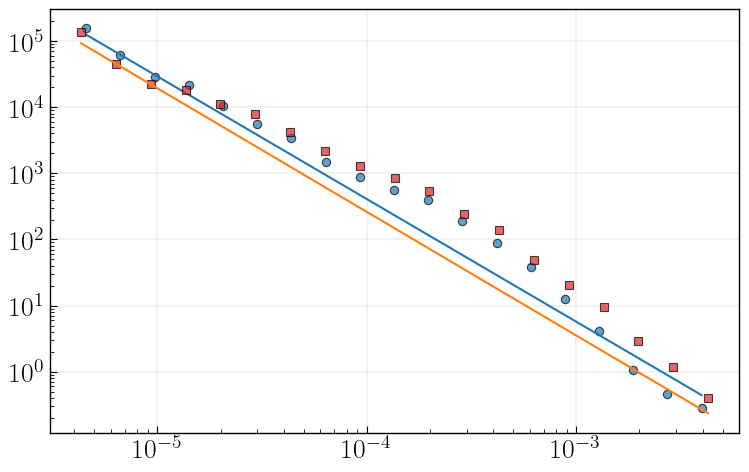

In [72]:
colors = ['tab:blue', 'tab:red']
markers = ['o', 's']
disc = False

if perform_fit:
    columns = ['tx_out', 'tx_in']
    labels = [r'$a^{out}$', r'$a^{in}$']

fig, ax = plt.subplots()


for idx, col in enumerate(columns):
    data = agents[col]
    data = data/data.sum()

    h = histogram(data,num_bins=21)
    plt.loglog(h[0],h[1],
            marker=markers[idx], 
            linestyle='', 
            markeredgecolor='k',
            alpha = 0.7, 
            label=labels[idx], 
            color=colors[idx],)
    x = np.linspace(h[0].min(),h[0].max(),200)
    y = x**-fits[col]['alpha']

    c = h[1][1] * h[0][1]**fits[col]['alpha']
    plt.plot(x,c*y)
